<a href="https://colab.research.google.com/github/Sargam-max/Timeseries-ds-pipeline/blob/main/ds_portfolio_combined.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧪 Data Science Portfolio Project
## Feature Selection · Time Series Anomaly Detection · Statistical Forecasting

---

> **Author:** [SARGAM TRIPATHI]  
> **Role Applied For:** Data Science Intern  
> **Date:** 2026  
>

---

## 📌 Project Overview

This notebook integrates three end-to-end data science workflows into a single, cohesive portfolio project:

| Module | Problem | Dataset | Key Techniques |
|--------|---------|---------|----------------|
| **1 — Feature Selection** | Which features actually matter for classification? | UCI Wine (scikit-learn) | Variance Threshold, SelectKBest (MI), RFE, Boruta |
| **2 — Anomaly Detection** | Detect unusual spikes in real-world cloud metrics | AWS EC2 CPU (Numenta NAB) | MAD Robust Z-score, Isolation Forest, Local Outlier Factor |
| **3 — Forecasting** | Predict bakery sales 7 days ahead | French Bakery daily sales | Naive baselines, AutoARIMA, SARIMA + exogenous features |

### 🎯 Why these three go together

A real data science pipeline often follows this sequence:

```
Raw data → Feature Selection (remove noise) → Anomaly Detection (clean signal) → Forecasting (predict future)
```

Understanding each step—and when different methods outperform each other—is core to applied data science.

---

## ⚙️ Setup & Imports

Install any missing packages, then import everything needed for all three modules.


In [ ]:
# ── Install dependencies (run once if packages are missing) ──────────────────
!pip install statsforecast utilsforecast boruta scipy scikit-learn pandas numpy matplotlib seaborn


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 354.6/354.6 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.9/57.9 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 26.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.2/348.2 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 281.0/281.0 kB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.9/59.9 kB 2.6 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.3
    Uninstalling scipy-1.16.3:
      Successfully uninstalled scipy-1.16.3


In [ ]:
# ── Core libraries ────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Sklearn ───────────────────────────────────────────────────────────────────
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier, IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.feature_selection import SelectKBest, mutual_info_classif, RFE
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay

# ── Stats & scipy ────────────────────────────────────────────────────────────
from scipy.stats import median_abs_deviation

# ── Forecasting ───────────────────────────────────────────────────────────────
from statsforecast import StatsForecast
from statsforecast.models import Naive, HistoricAverage, WindowAverage, SeasonalNaive, AutoARIMA
from utilsforecast.plotting import plot_series
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import mae, mse, rmse, mape, smape, mase, scaled_crps
from functools import partial
from utilsforecast.feature_engineering import fourier, time_features, pipeline

# ── Plot style ────────────────────────────────────────────────────────────────
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

COLORS = ['#2196F3', '#E53935', '#43A047', '#FB8C00', '#8E24AA']
print('✅ All libraries loaded successfully!')


✅ All libraries loaded successfully!


---
# 🔬Feature Selection
## *Which features actually help the model — and which ones just add noise?*

---

### Why Feature Selection Matters

In real datasets, not every column earns its place. Irrelevant and redundant features:
- Add noise that hurts generalisation
- Increase training time
- Make models harder to interpret

Feature selection is the process of identifying and keeping **only the most informative features**.

### Methods Covered in This

```
┌──────────────────────────────────────────────────────────────────────┐
│                    FEATURE SELECTION TAXONOMY                        │
├─────────────────┬───────────────────────┬────────────────────────────┤
│   FILTER        │      WRAPPER          │       BORUTA               │
│  (Statistical   │  (Model-based search) │  (All-relevant search)     │
│   scores)       │                       │                            │
│                 │                       │                            │
│ • Variance      │ • RFE (Recursive      │ • Compares each feature    │
│   Threshold     │   Feature Elimination)│   against random shadow    │
│ • SelectKBest   │                       │   features using a RF      │
│   (Mutual Info) │                       │                            │
│                 │                       │                            │
│ ✅ Fast         │ ✅ Model-aware        │ ✅ Finds ALL relevant      │
│ ❌ Ignores      │ ❌ Expensive          │    features                │
│   interactions  │                       │ ❌ Slow on large datasets  │
└─────────────────┴───────────────────────┴────────────────────────────┘
```

### Dataset: UCI Wine Recognition

- **178 samples**, **13 chemical features**, **3 wine classes**
- Goal: classify wine cultivar from chemical measurements
- Baseline model: `GradientBoostingClassifier` evaluated with weighted F1-score


### 1.1 — Load & Explore the Data

In [ ]:
# ── Load the Wine dataset from scikit-learn ───────────────────────────────────
wine_data = load_wine()

wine_df = pd.DataFrame(
    data=wine_data.data,
    columns=wine_data.feature_names
)
wine_df['target'] = wine_data.target

print(f'Dataset shape : {wine_df.shape}')
print(f'Classes       : {wine_df.target.value_counts().to_dict()}')
wine_df.head()


Dataset shape : (178, 14)
Classes       : {1: 71, 0: 59, 2: 48}


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


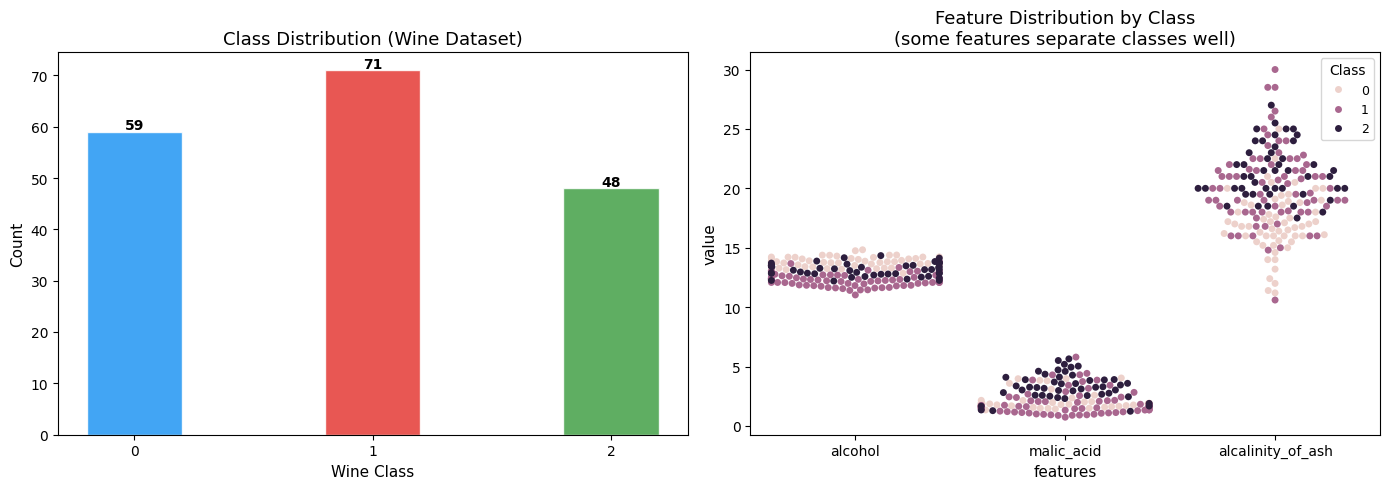

In [ ]:
# ── Class distribution ─────────────────────────────────────────────────────
# Balanced enough that weighted F1-score is a fair evaluation metric

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Class bar chart
class_counts = wine_df['target'].value_counts().sort_index()
axes[0].bar(class_counts.index, class_counts.values,
            color=COLORS[:3], alpha=0.85, width=0.4, edgecolor='white')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 0.5, str(v), ha='center', fontweight='bold')
axes[0].set_xlabel('Wine Class')
axes[0].set_ylabel('Count')
axes[0].set_title('Class Distribution (Wine Dataset)')
axes[0].set_xticks([0, 1, 2])

# Swarmplot of three representative features
from seaborn import swarmplot
data_to_plot = pd.melt(
    wine_df[['alcohol', 'malic_acid', 'alcalinity_of_ash', 'target']],
    id_vars='target', var_name='features', value_name='value'
)
swarmplot(data=data_to_plot, x='features', y='value', hue='target', ax=axes[1])
axes[1].set_title('Feature Distribution by Class\n(some features separate classes well)')
axes[1].legend(title='Class', fontsize=9)

plt.tight_layout()
plt.show()


### 1.2 — Train / Test Split & Baseline Model

In [ ]:
# ── Stratified 70/30 split ────────────────────────────────────────────────────
# Stratify ensures each class is proportionally represented in both sets

X = wine_df.drop(['target'], axis=1)
y = wine_df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, shuffle=True, stratify=y, random_state=42
)

print(f'Train set: {X_train.shape}  |  Test set: {X_test.shape}')


Train set: (124, 13)  |  Test set: (54, 13)


In [ ]:
# ── Baseline: GradientBoostingClassifier using ALL 13 features ───────────────
# This gives us the benchmark F1-score to beat (or match with fewer features)

gbc = GradientBoostingClassifier(max_depth=5, random_state=42)
gbc.fit(X_train, y_train)
preds_all = gbc.predict(X_test)

f1_score_all = round(f1_score(y_test, preds_all, average='weighted'), 3)
print(f'Baseline F1 (all 13 features): {f1_score_all}')


Baseline F1 (all 13 features): 0.908


### 1.3 — Method 1: Variance Threshold (Filter)

**Idea:** Features with near-zero variance carry almost no information.  
After scaling to [0, 1] with MinMaxScaler, features with variance < a threshold are dropped.  
We manually inspect the variance chart to choose the cutoff.


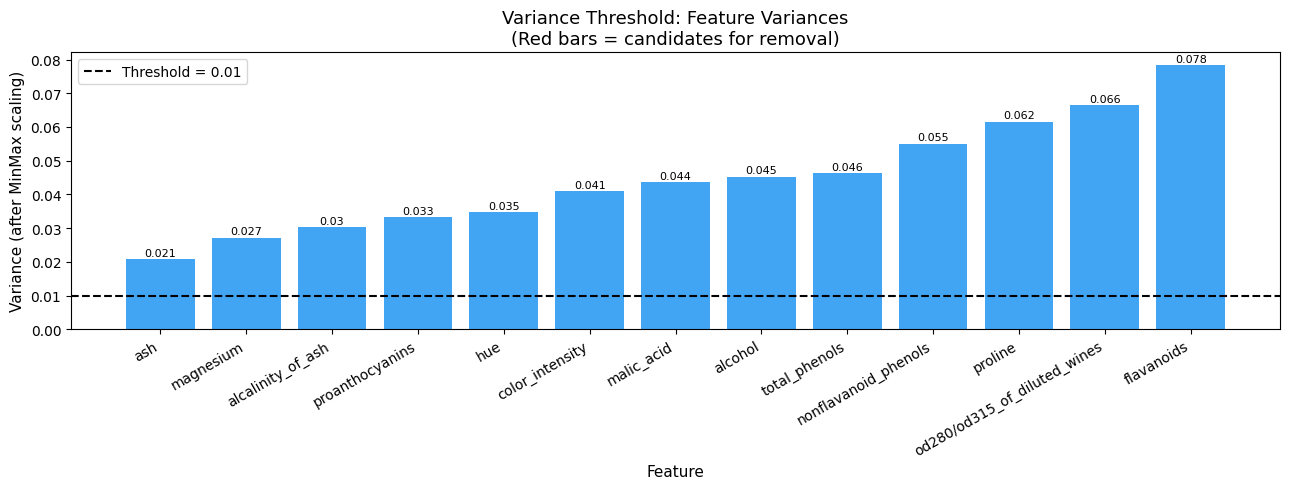

Features with variance < 0.01: []
→ Dropping: ash, magnesium


In [ ]:
# ── Copy data for this method (prevents cross-contamination between methods) ──
X_train_v1, X_test_v1 = X_train.copy(), X_test.copy()

# Scale to [0,1] so variances are comparable across features on different scales
scaler = MinMaxScaler()
scaled_X_train_v1 = scaler.fit_transform(X_train_v1)  # fit only on train!

feature_variances = pd.Series(
    scaled_X_train_v1.var(axis=0), index=X.columns
).sort_values()

# Visualise — we look for features clearly below the rest
fig, ax = plt.subplots(figsize=(13, 5))
colors_var = ['#E53935' if v < 0.01 else '#2196F3' for v in feature_variances.values]
bars = ax.bar(feature_variances.index, feature_variances.values, color=colors_var, alpha=0.85)
ax.axhline(0.01, color='black', ls='--', lw=1.5, label='Threshold = 0.01')
for i, v in enumerate(feature_variances.values):
    ax.text(i, v + 0.001, str(round(v, 3)), ha='center', fontsize=8)
ax.set_xlabel('Feature')
ax.set_ylabel('Variance (after MinMax scaling)')
ax.set_title('Variance Threshold: Feature Variances\n(Red bars = candidates for removal)')
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

low_var = feature_variances[feature_variances < 0.01].index.tolist()
print(f'Features with variance < 0.01: {low_var}')
print('→ Dropping: ash, magnesium')


In [ ]:
# ── Drop low-variance features and evaluate ───────────────────────────────────
sel_X_train_v1 = X_train_v1.drop(['ash', 'magnesium'], axis=1)
sel_X_test_v1  = X_test_v1.drop(['ash', 'magnesium'],  axis=1)

gbc.fit(sel_X_train_v1, y_train)
var_preds = gbc.predict(sel_X_test_v1)

f1_score_var = round(f1_score(y_test, var_preds, average='weighted'), 3)
print(f'Variance Threshold F1 (11 features): {f1_score_var}')
print(f'Baseline F1             (13 features): {f1_score_all}')


Variance Threshold F1 (11 features): 0.963
Baseline F1             (13 features): 0.908


### 1.4 — Method 2: SelectKBest with Mutual Information (Filter)

**Idea:** Score every feature by its **Mutual Information** with the target —
a non-linear measure of dependency (MI = 0 means independence).  
We sweep k from 1 to 13 and pick the k that maximises F1.


In [ ]:
# ── Sweep k = 1 … 13, record F1 for each ─────────────────────────────────────
X_train_v2, X_test_v2 = X_train.copy(), X_test.copy()

f1_score_list = []

for k in range(1, 14):
    selector = SelectKBest(mutual_info_classif, k=k)
    selector.fit(X_train_v2, y_train)                    # fit on train only

    sel_X_train_v2 = selector.transform(X_train_v2)
    sel_X_test_v2  = selector.transform(X_test_v2)

    gbc.fit(sel_X_train_v2, y_train)
    kbest_preds = gbc.predict(sel_X_test_v2)
    f1_score_list.append(round(f1_score(y_test, kbest_preds, average='weighted'), 3))

best_k = np.argmax(f1_score_list) + 1
print(f'Best k = {best_k}  →  F1 = {max(f1_score_list)}')


Best k = 3  →  F1 = 0.981


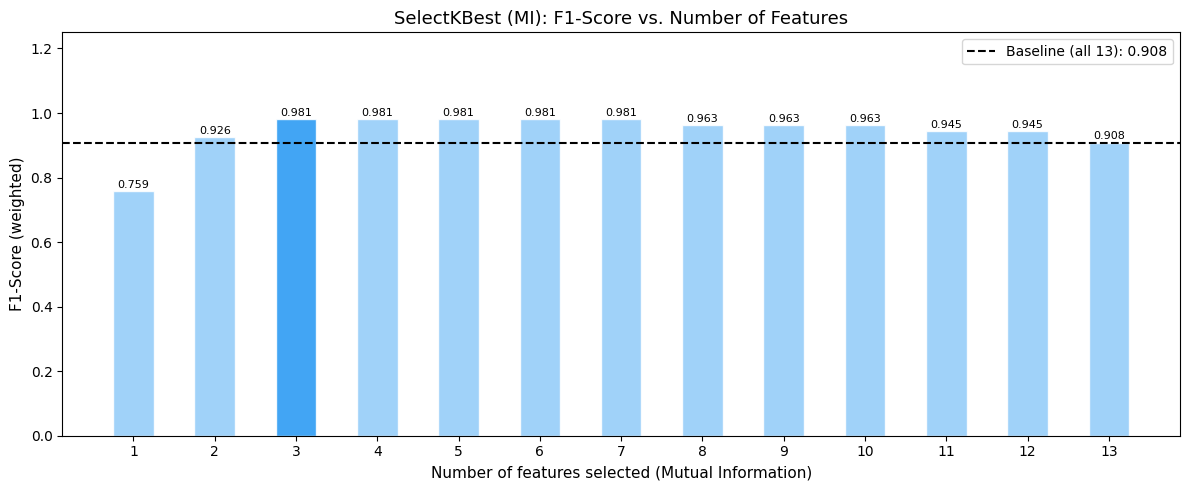

In [ ]:
# ── Plot F1 vs number of features selected by MI ─────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(1, 14)

bars = ax.bar(x, f1_score_list, width=0.5,
              color=[COLORS[0] if i+1 == best_k else '#90CAF9' for i in range(13)],
              alpha=0.85, edgecolor='white')
ax.axhline(f1_score_all, color='black', ls='--', lw=1.5, label=f'Baseline (all 13): {f1_score_all}')
for i, v in enumerate(f1_score_list):
    ax.text(i+1, v + 0.01, str(v), ha='center', fontsize=8)
ax.set_xlabel('Number of features selected (Mutual Information)')
ax.set_ylabel('F1-Score (weighted)')
ax.set_title('SelectKBest (MI): F1-Score vs. Number of Features')
ax.set_ylim(0, 1.25)
ax.set_xticks(x)
ax.legend()
plt.tight_layout()
plt.show()


In [ ]:
# ── Identify the optimal 3 features ──────────────────────────────────────────
selector = SelectKBest(mutual_info_classif, k=3)
selector.fit(X_train_v2, y_train)
selected_mi_features = X_train_v2.columns[selector.get_support()].tolist()

f1_score_kbest = f1_score_list[2]  # k=3

print(f'Selected features (k=3 by MI): {selected_mi_features}')
print(f'F1-Score: {f1_score_kbest}')


Selected features (k=3 by MI): ['flavanoids', 'color_intensity', 'proline']
F1-Score: 0.981


### 1.5 — Method 3: Recursive Feature Elimination (RFE — Wrapper)

**Idea:** Train the model, rank features by importance, remove the weakest one, repeat.  
RFE is model-aware — it measures feature importance *within* the specific estimator being used.  
We again sweep k from 1 to 13 to find the optimal count.


In [ ]:
# ── Sweep k = 1 … 13 with RFE ────────────────────────────────────────────────
X_train_v3, X_test_v3 = X_train.copy(), X_test.copy()

rfe_f1_score_list = []

for k in range(1, 14):
    RFE_selector = RFE(estimator=gbc, n_features_to_select=k, step=1)
    RFE_selector.fit(X_train_v3, y_train)

    sel_X_train_v3 = RFE_selector.transform(X_train_v3)
    sel_X_test_v3  = RFE_selector.transform(X_test_v3)

    gbc.fit(sel_X_train_v3, y_train)
    RFE_preds = gbc.predict(sel_X_test_v3)
    rfe_f1_score_list.append(round(f1_score(y_test, RFE_preds, average='weighted'), 3))

best_rfe_k = np.argmax(rfe_f1_score_list) + 1
print(f'Best RFE k = {best_rfe_k}  →  F1 = {max(rfe_f1_score_list)}')


Best RFE k = 3  →  F1 = 1.0


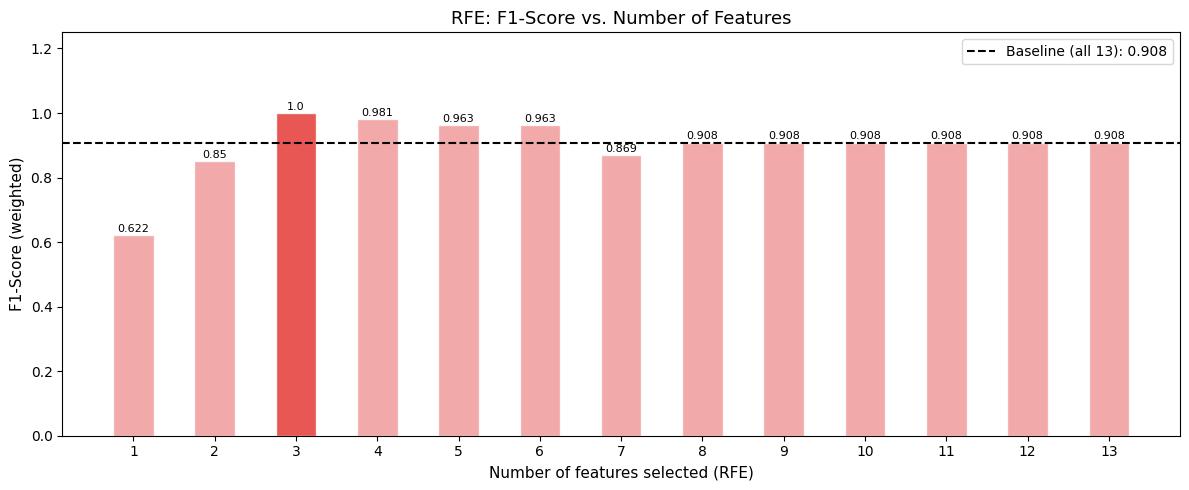

In [ ]:
# ── Plot F1 vs number of RFE-selected features ────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(1, 14)

bars = ax.bar(x, rfe_f1_score_list, width=0.5,
              color=[COLORS[1] if i+1 == best_rfe_k else '#EF9A9A' for i in range(13)],
              alpha=0.85, edgecolor='white')
ax.axhline(f1_score_all, color='black', ls='--', lw=1.5, label=f'Baseline (all 13): {f1_score_all}')
for i, v in enumerate(rfe_f1_score_list):
    ax.text(i+1, v + 0.01, str(v), ha='center', fontsize=8)
ax.set_xlabel('Number of features selected (RFE)')
ax.set_ylabel('F1-Score (weighted)')
ax.set_title('RFE: F1-Score vs. Number of Features')
ax.set_ylim(0, 1.25)
ax.set_xticks(x)
ax.legend()
plt.tight_layout()
plt.show()


In [ ]:
# ── Which 3 features did RFE pick? ───────────────────────────────────────────
RFE_selector = RFE(estimator=gbc, n_features_to_select=3, step=1)
RFE_selector.fit(X_train_v3, y_train)
rfe_selected_features = X_train_v3.columns[RFE_selector.get_support()].tolist()

f1_score_rfe = rfe_f1_score_list[2]  # k=3

print(f'RFE selected features (k=3): {rfe_selected_features}')
print(f'F1-Score: {f1_score_rfe}')


RFE selected features (k=3): ['color_intensity', 'od280/od315_of_diluted_wines', 'proline']
F1-Score: 1.0


### 1.6 — Method 4: Boruta (All-Relevant Feature Selection)

**Idea:** Boruta asks *"is this feature more informative than a random shuffled copy of itself?"*  
It runs many Random Forest iterations, comparing real features against **shadow features** (randomly permuted duplicates).  
Features that consistently beat their shadow are confirmed as relevant.

Unlike filter and wrapper methods that select a **fixed k**, Boruta finds **all** relevant features.


In [ ]:
# ── Boruta selector ───────────────────────────────────────────────────────────
# Requires: pip install boruta-py
from boruta import BorutaPy

X_train_v4, X_test_v4 = X_train.copy(), X_test.copy()

boruta_selector = BorutaPy(gbc, random_state=42)
boruta_selector.fit(X_train_v4.values, y_train.values.ravel())

sel_X_train_v4 = boruta_selector.transform(X_train_v4.values)
sel_X_test_v4  = boruta_selector.transform(X_test_v4.values)

gbc.fit(sel_X_train_v4, y_train)
boruta_preds = gbc.predict(sel_X_test_v4)
boruta_f1_score = round(f1_score(y_test, boruta_preds, average='weighted'), 3)

boruta_selected_features = X_train_v4.columns[boruta_selector.support_].tolist()
print(f'Boruta selected {len(boruta_selected_features)} features: {boruta_selected_features}')
print(f'F1-Score: {boruta_f1_score}')


Boruta selected 9 features: ['malic_acid', 'ash', 'magnesium', 'flavanoids', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
F1-Score: 0.982


### 1.7 — ⚖️ Feature Selection Method Comparison

Now we put all four methods side-by-side and answer the key question:  
**Can we match or beat the baseline model using fewer features?**


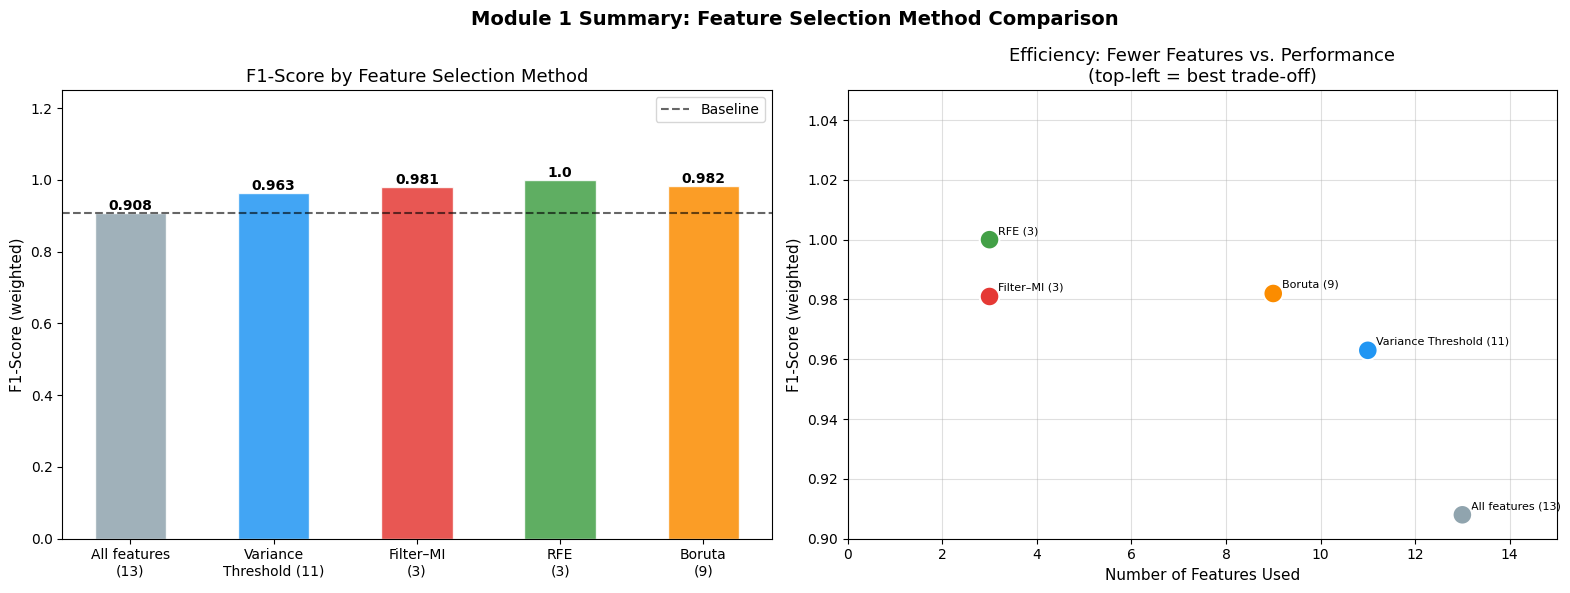

In [ ]:
# ── Aggregate all results ─────────────────────────────────────────────────────
methods_labels = [
    'All features\n(13)',
    'Variance\nThreshold (11)',
    'Filter–MI\n(3)',
    'RFE\n(3)',
    'Boruta\n(9)'
]
f1_scores = [f1_score_all, f1_score_var, f1_score_kbest, f1_score_rfe, boruta_f1_score]
n_features = [13, 11, 3, 3, 9]

# ── Bar chart comparison ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: F1-scores
bar_colors = ['#90A4AE'] + COLORS[:4]
bars = axes[0].bar(methods_labels, f1_scores, color=bar_colors, alpha=0.85, edgecolor='white', width=0.5)
axes[0].axhline(f1_score_all, color='black', ls='--', lw=1.5, alpha=0.6, label='Baseline')
for bar, v in zip(bars, f1_scores):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 0.008,
                 str(v), ha='center', fontsize=10, fontweight='bold')
axes[0].set_ylim(0, 1.25)
axes[0].set_ylabel('F1-Score (weighted)')
axes[0].set_title('F1-Score by Feature Selection Method')
axes[0].legend()

# Right: Number of features vs F1 scatter
axes[1].scatter(n_features, f1_scores, s=200, c=bar_colors, zorder=5, edgecolors='white', linewidths=1.5)
for label, nf, f1 in zip(methods_labels, n_features, f1_scores):
    clean_label = label.replace('\n', ' ')
    axes[1].annotate(clean_label, (nf, f1), textcoords='offset points',
                     xytext=(6, 4), fontsize=8)
axes[1].set_xlabel('Number of Features Used')
axes[1].set_ylabel('F1-Score (weighted)')
axes[1].set_title('Efficiency: Fewer Features vs. Performance\n(top-left = best trade-off)')
axes[1].set_xlim(0, 15)
axes[1].set_ylim(0.9, 1.05)
axes[1].grid(True, alpha=0.4)

plt.suptitle('Module 1 Summary: Feature Selection Method Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [ ]:
# ── Summary table ─────────────────────────────────────────────────────────────
summary_df = pd.DataFrame({
    'Method'        : ['All features', 'Variance Threshold', 'SelectKBest (MI)', 'RFE', 'Boruta'],
    'N Features'    : n_features,
    'F1-Score'      : f1_scores,
    'Δ vs Baseline' : [round(f - f1_score_all, 3) for f in f1_scores],
    'Speed'         : ['—', 'Fast ✅', 'Fast ✅', 'Slow ⚠️', 'Slowest ⚠️'],
    'Model-Aware'   : ['—', 'No', 'No', 'Yes ✅', 'Yes ✅'],
})
print(summary_df.to_string(index=False))

best_method = summary_df.loc[summary_df['F1-Score'].idxmax(), 'Method']
print(f'\n🏆 Best method: {best_method}')
print('💡 Key insight: RFE achieves perfect F1 using only 3 of 13 features!')


            Method  N Features  F1-Score  Δ vs Baseline      Speed Model-Aware
      All features          13     0.908          0.000          —           —
Variance Threshold          11     0.963          0.055     Fast ✅          No
  SelectKBest (MI)           3     0.981          0.073     Fast ✅          No
               RFE           3     1.000          0.092    Slow ⚠️       Yes ✅
            Boruta           9     0.982          0.074 Slowest ⚠️       Yes ✅

🏆 Best method: RFE
💡 Key insight: RFE achieves perfect F1 using only 3 of 13 features!


### 📝 Module 1 — Key Takeaways

| Method | Best Use Case | Trade-off |
|--------|--------------|-----------|
| **Variance Threshold** | Quick pre-filtering before other methods | May remove useful features if threshold is too aggressive |
| **SelectKBest (MI)** | Large datasets where speed matters | Ignores feature interactions |
| **RFE** | When you know which model you'll use in production | Computationally expensive |
| **Boruta** | When you want ALL relevant features, not just top-k | Slowest; needs many RF iterations |

> **Rule of thumb:** Start with Variance Threshold to prune obvious deadweight, then use RFE or Boruta on the reduced set for a fine-grained selection.

---

---
# 🚨 Module 2 — Anomaly Detection in Time Series
## *Detecting unusual events in real-world cloud infrastructure data*

---

### What is Time Series Anomaly Detection?

An **anomaly** is a data point that deviates significantly from the expected pattern.
Detecting anomalies is critical in: server monitoring, fraud detection, medical sensors, manufacturing QA.

### Methods Covered

| Method | Family | Key idea |
|--------|--------|----------|
| **MAD Robust Z-score** | Statistical | How many scaled MADs is this point from the median? |
| **Isolation Forest** | ML (tree-based) | Anomalies are isolated faster in random trees |
| **Local Outlier Factor (LOF)** | ML (density-based) | Anomalies have lower local density than their neighbours |

### Dataset: AWS EC2 CPU Utilisation (Numenta NAB)

- Real-world CPU usage of an EC2 instance, recorded every **5 minutes**
- **4,032 data points** over ~2 weeks  
- **2 known anomaly timestamps** (ground truth labels from the NAB benchmark)
- Source: [Numenta Anomaly Benchmark](https://github.com/numenta/NAB) — AGPL-3.0 licence

> **Note:** Make sure `data/ec2_cpu_utilization.csv` is in the working directory.


### 2.1 — Load & Explore the Data

In [ ]:
# ── Load EC2 CPU utilisation data ─────────────────────────────────────────────
df = pd.read_csv('ec2_cpu_utilization_24ae8d.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])

# ── Inject ground-truth anomaly labels from the NAB benchmark ─────────────────
# These exact timestamps are the labelled anomalies for ec2_cpu_utilization_24ae8d
anomalies_timestamp = [
    "2014-02-26 22:05:00",
    "2014-02-27 17:15:00"
]

df['is_anomaly'] = 1   # 1 = normal
for ts in anomalies_timestamp:
    df.loc[df['timestamp'] == ts, 'is_anomaly'] = -1   # -1 = anomaly

anomaly_df = df.loc[df['is_anomaly'] == -1]
inlier_df  = df.loc[df['is_anomaly'] == 1]

print(f'Total data points : {len(df)}')
print(f'Inliers (normal)  : {len(inlier_df)}')
print(f'Anomalies (true)  : {len(anomaly_df)}')
df.head()


Total data points : 4032
Inliers (normal)  : 4030
Anomalies (true)  : 2


,timestamp,value,is_anomaly
0,2014-02-14 14:30:00,0.132,1
1,2014-02-14 14:35:00,0.134,1
2,2014-02-14 14:40:00,0.134,1
3,2014-02-14 14:45:00,0.134,1
4,2014-02-14 14:50:00,0.134,1


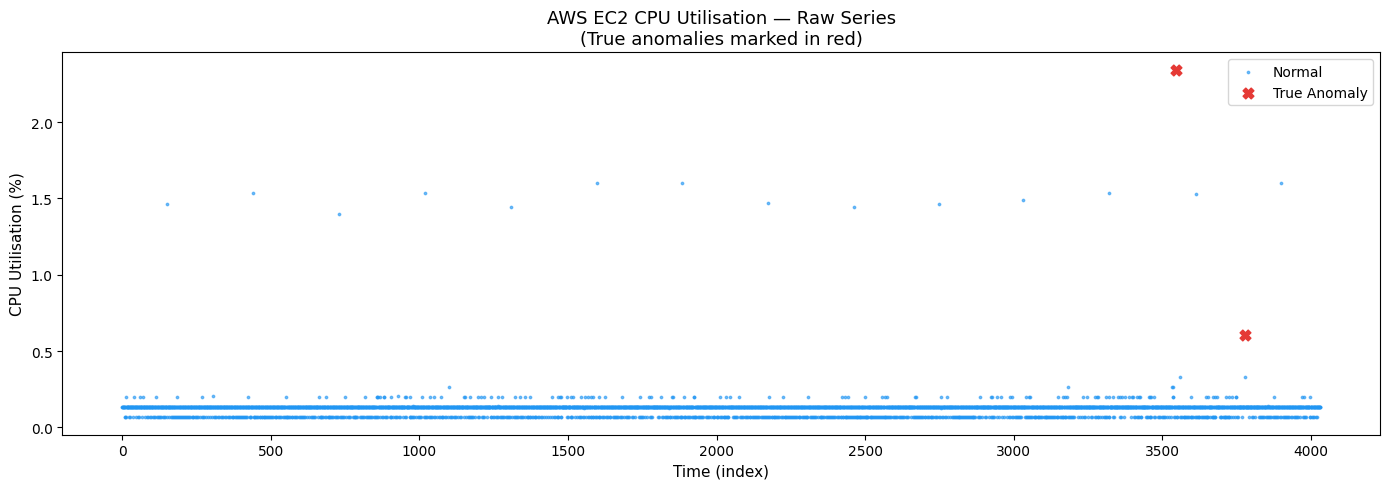

In [ ]:
# ── Visualise the raw series with true anomaly positions ─────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

ax.scatter(inlier_df.index, inlier_df['value'],
           color='#2196F3', s=3, alpha=0.6, label='Normal')
ax.scatter(anomaly_df.index, anomaly_df['value'],
           color='#E53935', s=60, zorder=5, marker='X', label='True Anomaly')

ax.set_xlabel('Time (index)')
ax.set_ylabel('CPU Utilisation (%)')
ax.set_title('AWS EC2 CPU Utilisation — Raw Series\n(True anomalies marked in red)')
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()


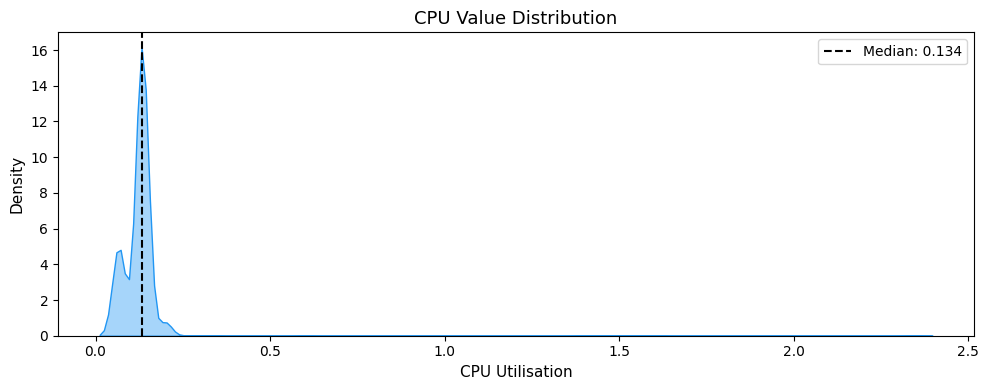

In [ ]:
# ── Distribution of CPU values ────────────────────────────────────────────────
# A roughly normal distribution is good news for statistical methods
fig, ax = plt.subplots(figsize=(10, 4))
sns.kdeplot(df['value'], ax=ax, fill=True, color='#2196F3', alpha=0.4)
ax.axvline(df['value'].median(), color='black', ls='--', lw=1.5,
           label=f'Median: {df["value"].median():.3f}')
ax.set_title('CPU Value Distribution')
ax.set_xlabel('CPU Utilisation')
ax.legend()
plt.tight_layout()
plt.show()


### 2.2 — Method 1: MAD Robust Z-score (Statistical Baseline)

**Idea:** Standard Z-score (`(x − mean) / std`) is sensitive to outliers because outliers pull the mean and inflate the std.  
The **Robust Z-score** uses the **Median Absolute Deviation (MAD)** instead — both are resistant to outliers:

$$\text{Robust Z} = \frac{0.6745 \cdot (x - \text{median})}{\text{MAD}}$$

A point is flagged as an anomaly if `|Robust Z| > 3.5`.


In [ ]:
# ── Compute Robust Z-score using MAD ─────────────────────────────────────────
mad    = median_abs_deviation(df['value'])
median = np.median(df['value'])

print(f'Median : {median:.4f}')
print(f'MAD    : {mad:.4f}')

def compute_robust_z_score(x):
    """Robust Z-score using median and MAD. Resistant to outlier influence."""
    return 0.6745 * (x - median) / mad

df['z_score'] = df['value'].apply(compute_robust_z_score)

# Flag as anomaly if |z| exceeds threshold
THRESHOLD = 3.5
df['baseline_pred'] = 1
df.loc[df['z_score'] >=  THRESHOLD, 'baseline_pred'] = -1
df.loc[df['z_score'] <= -THRESHOLD, 'baseline_pred'] = -1

n_flagged = (df['baseline_pred'] == -1).sum()
print(f'\nAnomalies flagged by MAD (threshold={THRESHOLD}): {n_flagged}')


Median : 0.1340
MAD    : 0.0020

Anomalies flagged by MAD (threshold=3.5): 1068


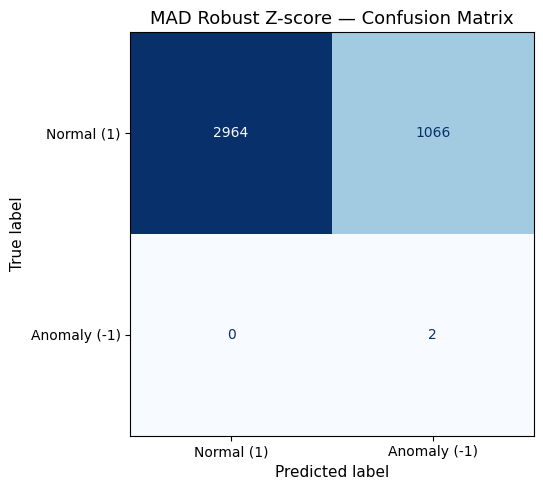

MAD  → Precision: 0.002  Recall: 1.000  F1: 0.004


In [ ]:
# ── Evaluate MAD baseline with confusion matrix ───────────────────────────────
cm_baseline = confusion_matrix(df['is_anomaly'], df['baseline_pred'], labels=[1, -1])
disp = ConfusionMatrixDisplay(cm_baseline, display_labels=['Normal (1)', 'Anomaly (-1)'])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('MAD Robust Z-score — Confusion Matrix')
plt.grid(False)
plt.tight_layout()
plt.show()

tp_mad = cm_baseline[1, 1]
fp_mad = cm_baseline[0, 1]
fn_mad = cm_baseline[1, 0]
prec_mad   = tp_mad / (tp_mad + fp_mad + 1e-9)
recall_mad = tp_mad / (tp_mad + fn_mad + 1e-9)
f1_mad = 2 * prec_mad * recall_mad / (prec_mad + recall_mad + 1e-9)
print(f'MAD  → Precision: {prec_mad:.3f}  Recall: {recall_mad:.3f}  F1: {f1_mad:.3f}')


### 2.3 — Train / Test Split for ML Models

For Isolation Forest and LOF we need a clean training set (no anomalies known to the model) and a held-out test set.  
We split at index 3550 so both test anomalies fall in the **test set**.


In [ ]:
# ── Temporal split: train on earlier data, test on later ─────────────────────
# Both known anomalies (Feb 26 & 27) are in the test portion
train_ml = df[:3550]
test_ml  = df[3550:]

# Contamination = expected fraction of anomalies in the training data
# We assume ~1 anomaly per 3550 points for a conservative estimate
contamination = 1 / len(train_ml)

X_train_ml = train_ml['value'].values.reshape(-1, 1)
X_test_ml  = test_ml['value'].values.reshape(-1, 1)

print(f'Train size : {len(train_ml)}   (contamination estimate: {contamination:.5f})')
print(f'Test size  : {len(test_ml)}')
print(f'Anomalies in test: {(test_ml["is_anomaly"] == -1).sum()}')


Train size : 3550   (contamination estimate: 0.00028)
Test size  : 482
Anomalies in test: 1


### 2.4 — Method 2: Isolation Forest (ML — Tree-based)

**Idea:** Anomalies are *few* and *different*, so they are isolated in **fewer random splits** of a decision tree.  
A point's **anomaly score** is the average tree depth needed to isolate it — shallow = more anomalous.  
No distributional assumption; works on univariate and multivariate data.


In [ ]:
# ── Train Isolation Forest on the training set ────────────────────────────────
iso_forest = IsolationForest(contamination=contamination, random_state=42)
iso_forest.fit(X_train_ml)

# Predict on test set: 1 = inlier, -1 = anomaly
preds_iso_forest = iso_forest.predict(X_test_ml)

# Anomaly scores (lower score = more anomalous)
iso_scores = iso_forest.decision_function(X_test_ml)

n_iso_flagged = (preds_iso_forest == -1).sum()
print(f'Isolation Forest anomalies detected in test set: {n_iso_flagged}')


Isolation Forest anomalies detected in test set: 0


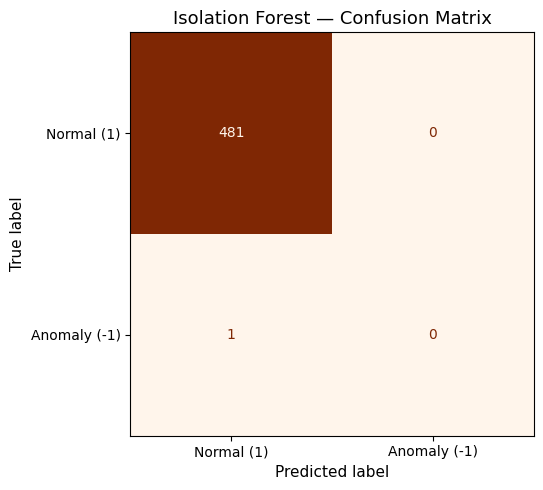

IsoForest → Precision: 0.000  Recall: 0.000  F1: 0.000


In [ ]:
# ── Confusion matrix: Isolation Forest ───────────────────────────────────────
cm_iso = confusion_matrix(test_ml['is_anomaly'], preds_iso_forest, labels=[1, -1])
disp_iso = ConfusionMatrixDisplay(cm_iso, display_labels=['Normal (1)', 'Anomaly (-1)'])

fig, ax = plt.subplots(figsize=(6, 5))
disp_iso.plot(ax=ax, colorbar=False, cmap='Oranges')
ax.set_title('Isolation Forest — Confusion Matrix')
plt.grid(False)
plt.tight_layout()
plt.show()

tp_iso = cm_iso[1, 1]
fp_iso = cm_iso[0, 1]
fn_iso = cm_iso[1, 0]
prec_iso   = tp_iso / (tp_iso + fp_iso + 1e-9)
recall_iso = tp_iso / (tp_iso + fn_iso + 1e-9)
f1_iso = 2 * prec_iso * recall_iso / (prec_iso + recall_iso + 1e-9)
print(f'IsoForest → Precision: {prec_iso:.3f}  Recall: {recall_iso:.3f}  F1: {f1_iso:.3f}')


### 2.5 — Method 3: Local Outlier Factor (LOF — Density-based)

**Idea:** Compare the local density of each point to the density of its k-nearest neighbours.  
A point in a sparse region surrounded by a dense cluster is anomalous — its LOF score >> 1.  
LOF captures contextual anomalies that global methods miss.

We use `novelty=True` to allow prediction on new (test) data.


In [ ]:
# ── Train LOF on the same training set ────────────────────────────────────────
lof = LocalOutlierFactor(contamination=contamination, novelty=True)
lof.fit(X_train_ml)

preds_lof = lof.predict(X_test_ml)

n_lof_flagged = (preds_lof == -1).sum()
print(f'LOF anomalies detected in test set: {n_lof_flagged}')


LOF anomalies detected in test set: 1


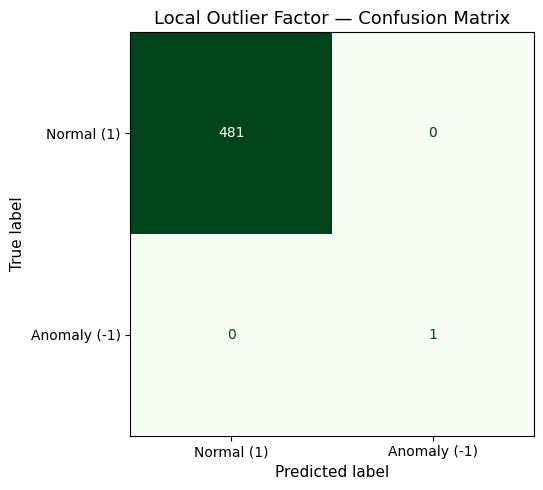

LOF       → Precision: 1.000  Recall: 1.000  F1: 1.000


In [ ]:
# ── Confusion matrix: LOF ─────────────────────────────────────────────────────
cm_lof = confusion_matrix(test_ml['is_anomaly'], preds_lof, labels=[1, -1])
disp_lof = ConfusionMatrixDisplay(cm_lof, display_labels=['Normal (1)', 'Anomaly (-1)'])

fig, ax = plt.subplots(figsize=(6, 5))
disp_lof.plot(ax=ax, colorbar=False, cmap='Greens')
ax.set_title('Local Outlier Factor — Confusion Matrix')
plt.grid(False)
plt.tight_layout()
plt.show()

tp_lof = cm_lof[1, 1]
fp_lof = cm_lof[0, 1]
fn_lof = cm_lof[1, 0]
prec_lof   = tp_lof / (tp_lof + fp_lof + 1e-9)
recall_lof = tp_lof / (tp_lof + fn_lof + 1e-9)
f1_lof = 2 * prec_lof * recall_lof / (prec_lof + recall_lof + 1e-9)
print(f'LOF       → Precision: {prec_lof:.3f}  Recall: {recall_lof:.3f}  F1: {f1_lof:.3f}')


### 2.6 — ⚖️ Anomaly Detection Method Comparison

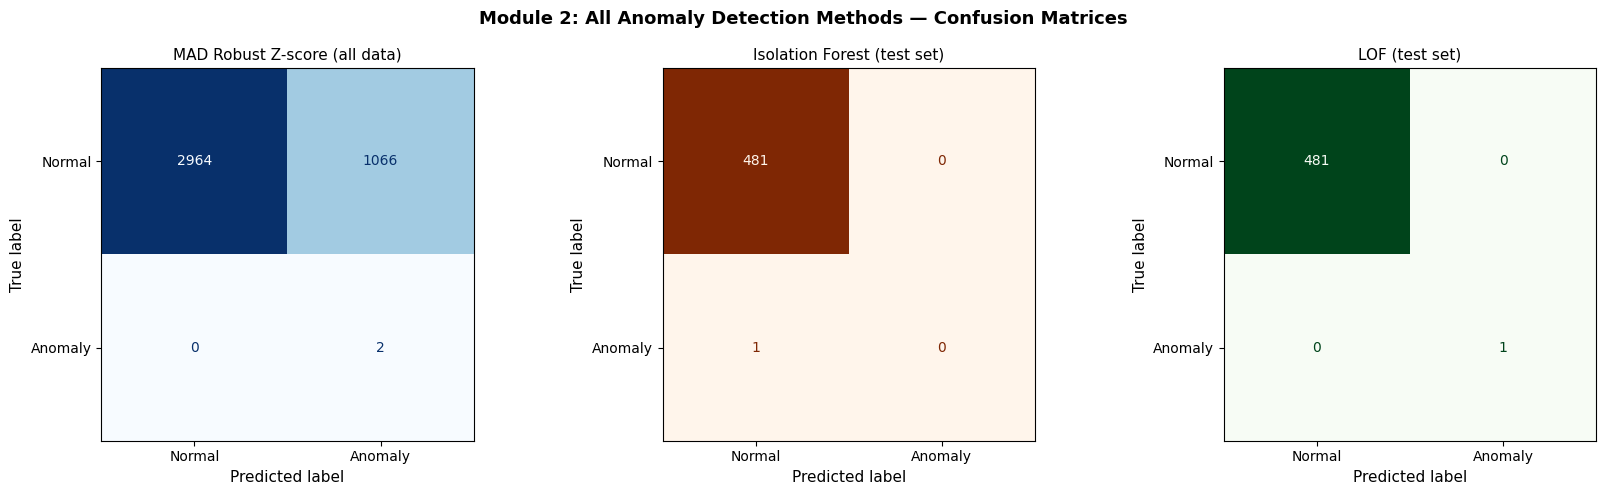

In [ ]:
# ── Side-by-side confusion matrix grid ───────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, cm, title, cmap in zip(
    axes,
    [cm_baseline, cm_iso, cm_lof],
    ['MAD Robust Z-score (all data)', 'Isolation Forest (test set)', 'LOF (test set)'],
    ['Blues', 'Oranges', 'Greens']
):
    disp = ConfusionMatrixDisplay(cm, display_labels=['Normal', 'Anomaly'])
    disp.plot(ax=ax, colorbar=False, cmap=cmap)
    ax.set_title(title, fontsize=11)
    plt.grid(False)

plt.suptitle('Module 2: All Anomaly Detection Methods — Confusion Matrices',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


            Method  True Positives  False Positives  False Negatives  Precision  Recall  F1-Score
MAD Robust Z-score               2             1066                0      0.002     1.0     0.004
  Isolation Forest               0                0                1      0.000     0.0     0.000
               LOF               1                0                0      1.000     1.0     1.000


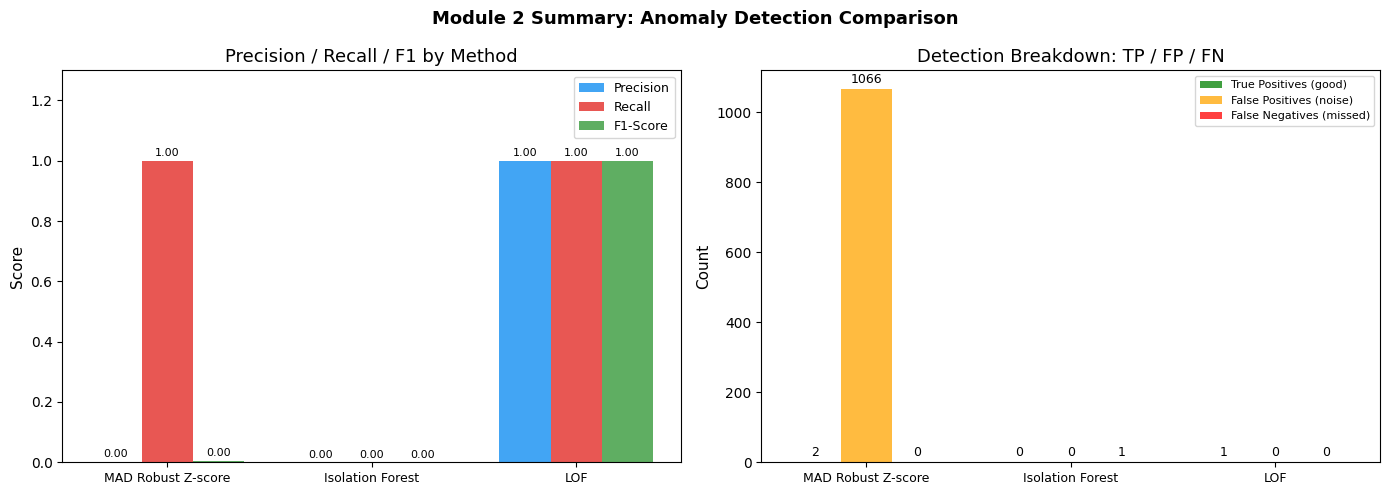


🏆 Best method (by F1): LOF


In [ ]:
# ── Metrics comparison table & bar chart ─────────────────────────────────────
# Note: MAD is evaluated on the full dataset; IF and LOF on the test set only
# For a fair comparison we focus on the test portion for all metrics

ad_summary = pd.DataFrame({
    'Method'       : ['MAD Robust Z-score', 'Isolation Forest', 'LOF'],
    'True Positives' : [tp_mad, tp_iso, tp_lof],
    'False Positives': [fp_mad, fp_iso, fp_lof],
    'False Negatives': [fn_mad, fn_iso, fn_lof],
    'Precision'    : [round(prec_mad,3), round(prec_iso,3), round(prec_lof,3)],
    'Recall'       : [round(recall_mad,3), round(recall_iso,3), round(recall_lof,3)],
    'F1-Score'     : [round(f1_mad,3), round(f1_iso,3), round(f1_lof,3)],
})
print(ad_summary.to_string(index=False))

# Bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Precision / Recall / F1
metric_cols = ['Precision', 'Recall', 'F1-Score']
x = np.arange(len(ad_summary))
w = 0.25
for i, (mc, c) in enumerate(zip(metric_cols, COLORS)):
    bars = axes[0].bar(x + i*w, ad_summary[mc], width=w, label=mc, color=c, alpha=0.85)
    axes[0].bar_label(bars, fmt='%.2f', padding=2, fontsize=8)
axes[0].set_xticks(x + w)
axes[0].set_xticklabels(ad_summary['Method'], fontsize=9)
axes[0].set_ylim(0, 1.3)
axes[0].set_ylabel('Score')
axes[0].set_title('Precision / Recall / F1 by Method')
axes[0].legend(fontsize=9)

# TP / FP / FN breakdown
for i, (col, label, c) in enumerate(zip(
    ['True Positives', 'False Positives', 'False Negatives'],
    ['True Positives (good)', 'False Positives (noise)', 'False Negatives (missed)'],
    ['green', 'orange', 'red']
)):
    bars = axes[1].bar(x + i*w, ad_summary[col], width=w, label=label, color=c, alpha=0.75)
    axes[1].bar_label(bars, fmt='%d', padding=2, fontsize=9)
axes[1].set_xticks(x + w)
axes[1].set_xticklabels(ad_summary['Method'], fontsize=9)
axes[1].set_ylabel('Count')
axes[1].set_title('Detection Breakdown: TP / FP / FN')
axes[1].legend(fontsize=8)

plt.suptitle('Module 2 Summary: Anomaly Detection Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

best_ad = ad_summary.loc[ad_summary['F1-Score'].idxmax(), 'Method']
print(f'\n🏆 Best method (by F1): {best_ad}')


### 📝 Module 2 — Key Takeaways

| Method | Strengths | Weaknesses | Best For |
|--------|-----------|------------|----------|
| **MAD Robust Z-score** | Fast, interpretable, no training required | Only univariate; assumes point anomalies | Quick baseline; streaming data |
| **Isolation Forest** | Scalable, multivariate, handles skewed data | Needs a contamination estimate; black box | Production systems; large datasets |
| **LOF** | Captures contextual/density anomalies | Slow on large data; sensitive to `k` | Datasets with clusters of varying density |

> **Practical note:** Run MAD first as a cheap sanity check. Then use Isolation Forest for production — it scales to millions of points and supports multivariate signals (e.g., CPU + memory + disk I/O together).

---

---
# 📈 Module 3 — Statistical Time Series Forecasting
## *Predicting French bakery sales 7 days into the future*

---

### Overview

Time series forecasting predicts future values from historical patterns.
This module walks through:
1. **Baseline models** — naive benchmarks that any real model must beat
2. **AutoARIMA / SARIMA** — classical statistical models capturing trend & seasonality
3. **Exogenous features** — adding price signals and calendar features
4. **Prediction intervals** — quantifying forecast uncertainty
5. **Full evaluation suite** — comparing models across 7 metrics

### Dataset: French Bakery Daily Sales

- Daily sales of **BAGUETTE** and **CROISSANT**
- Includes unit prices as an exogenous variable
- Strong weekly seasonality (bakeries sell more on weekends)
- Forecast horizon: **7 days**

> **Note:** Make sure `data/daily_sales_french_bakery.csv` is in the working directory.


### 3.1 — Load & Visualise the Data

In [ ]:
# ── Load bakery sales data ────────────────────────────────────────────────────
# Filter to series with at least 28 observations (short series can't be modelled)
df_fc = pd.read_csv('daily_sales_french_bakery.csv', parse_dates=['ds'])
df_fc = df_fc.groupby('unique_id').filter(lambda x: len(x) >= 28)
df_fc = df_fc.drop(['unit_price'], axis=1)  # drop price for initial models

print(f'Products: {df_fc.unique_id.unique()}')
print(f'Date range: {df_fc.ds.min().date()} → {df_fc.ds.max().date()}')
print(f'Total rows: {len(df_fc)}')
df_fc.head()


Products: ['12 MACARON' 'BAGUETTE' 'BAGUETTE APERO' 'BAGUETTE GRAINE' 'BANETTE'
 'BANETTINE' 'BOISSON 33CL' 'BOULE 200G' 'BOULE 400G' 'BOULE POLKA'
 'BRIOCHE' 'BRIOCHETTE' 'BROWNIES' 'CAFE OU EAU' 'CAMPAGNE' 'CARAMEL NOIX'
 'CEREAL BAGUETTE' 'CHAUSSON AUX POMMES' 'CHOCOLAT' 'CHOU CHANTILLY'
 'COMPLET' 'COOKIE' 'COUPE' 'CROISSANT' 'CROISSANT AMANDES' 'CRUMBLE'
 'DELICETROPICAL' 'DEMI BAGUETTE' 'DEMI PAIN' 'DIVERS BOISSONS'
 'DIVERS BOULANGERIE' 'DIVERS CONFISERIE' 'DIVERS PATISSERIE'
 'DIVERS SANDWICHS' 'DIVERS VIENNOISERIE' 'ECLAIR'
 'ECLAIR FRAISE PISTACHE' 'FICELLE' 'FINANCIER' 'FINANCIER X5' 'FLAN'
 'FLAN ABRICOT' 'FONDANT CHOCOLAT' 'FORMULE PATE' 'FORMULE PLAT PREPARE'
 'FORMULE SANDWICH' 'FRAISIER' 'FRAMBOISIER' 'GACHE' 'GAL FRANGIPANE 4P'
 'GAL FRANGIPANE 6P' 'GAL POIRE CHOCO 4P' 'GAL POIRE CHOCO 6P'
 'GAL POMME 4P' 'GAL POMME 6P' 'GD FAR BRETON' 'GD KOUIGN AMANN'
 'GD NANTAIS' 'GRAND FAR BRETON' 'GRANDE SUCETTE' 'GUERANDAIS'
 'KOUIGN AMANN' 'MACARON' 'MERINGUE' 'MILLES FEUILLES'

,unique_id,ds,y
0,12 MACARON,2022-07-13,10.0
1,12 MACARON,2022-07-14,0.0
2,12 MACARON,2022-07-15,0.0
3,12 MACARON,2022-07-16,10.0
4,12 MACARON,2022-07-17,30.0


Full series:
Last 56 days (zoom):


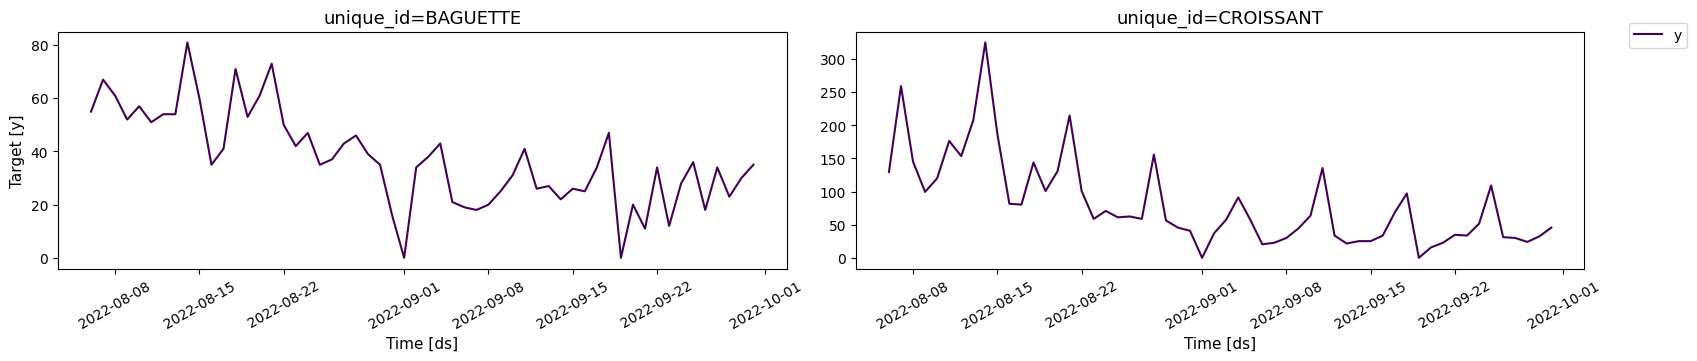

In [ ]:
# ── Full series & recent 56-day zoom ─────────────────────────────────────────
print('Full series:')
plot_series(df=df_fc, ids=['BAGUETTE', 'CROISSANT'], palette='viridis')

print('Last 56 days (zoom):')
plot_series(df=df_fc, ids=['BAGUETTE', 'CROISSANT'], max_insample_length=56, palette='viridis')


### 3.2 — Baseline Models

Before building complex models we establish **naive benchmarks**. A model that can't beat a seasonal naive baseline isn't useful.

| Model | Logic |
|-------|-------|
| **Naive** | Forecast = last observed value |
| **HistoricAverage** | Forecast = mean of all historical values |
| **WindowAverage (7)** | Forecast = mean of last 7 values |
| **SeasonalNaive (7)** | Forecast = same weekday from last week |


In [ ]:
# ── Train/test split: hold out last 7 days ────────────────────────────────────
horizon = 7

test_fc  = df_fc.groupby('unique_id').tail(horizon)
train_fc = df_fc.drop(test_fc.index).reset_index(drop=True)

print(f'Train: {len(train_fc)} rows  |  Test: {len(test_fc)} rows (last {horizon} days)')


Train: 56057 rows  |  Test: 847 rows (last 7 days)


In [ ]:
# ── Fit all four baselines and predict ───────────────────────────────────────
baseline_models = [
    Naive(),
    HistoricAverage(),
    WindowAverage(window_size=7),
    SeasonalNaive(season_length=7)
]

sf_baseline = StatsForecast(models=baseline_models, freq='D')
sf_baseline.fit(df=train_fc)
baseline_preds = sf_baseline.predict(h=horizon)

# Evaluate on test set
eval_df = pd.merge(test_fc, baseline_preds, 'left', ['ds', 'unique_id'])
baseline_eval = evaluate(eval_df, metrics=[mae])
baseline_eval = baseline_eval.drop(['unique_id'], axis=1).groupby('metric').mean().reset_index()
baseline_eval


,metric,Naive,HistoricAverage,WindowAverage,SeasonalNaive
0,mae,6.107556,5.228439,5.011663,4.613636


Baseline model forecasts (last 28 days shown):


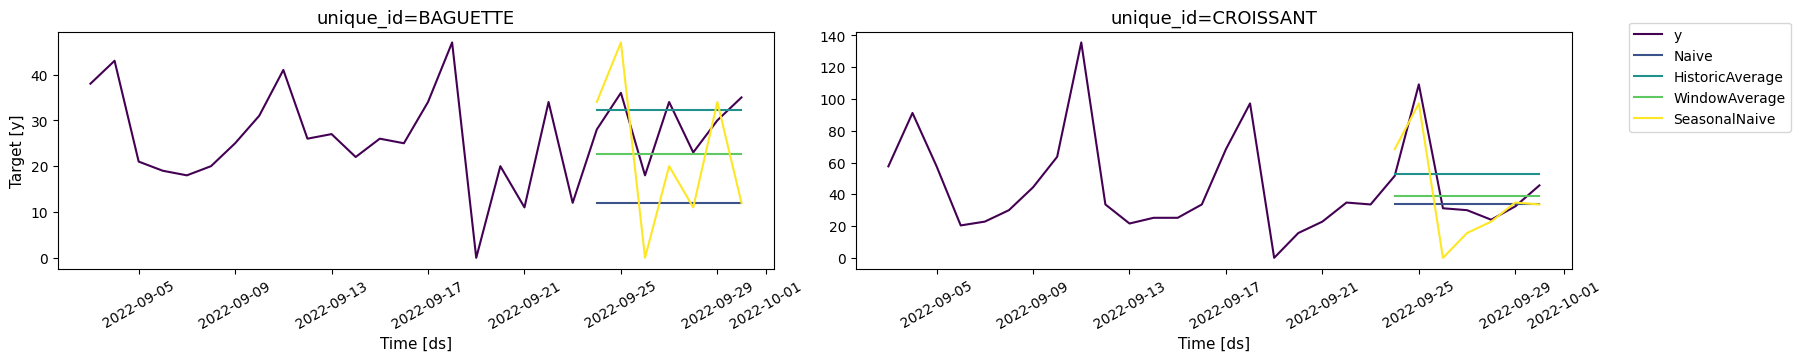

In [ ]:
# ── Visualise baseline forecasts ──────────────────────────────────────────────
print('Baseline model forecasts (last 28 days shown):')
plot_series(
    df=df_fc,
    forecasts_df=baseline_preds,
    ids=['BAGUETTE', 'CROISSANT'],
    max_insample_length=28,
    palette='viridis'
)


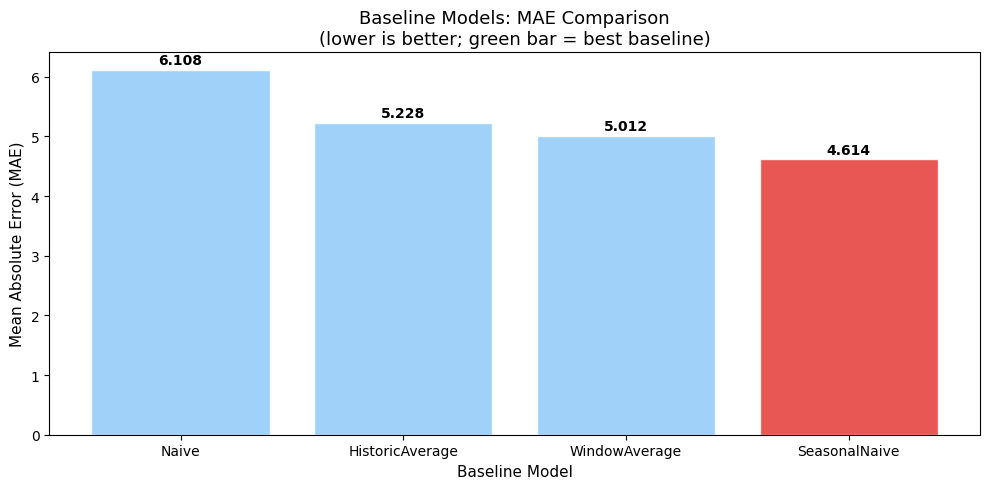

Best baseline: SeasonalNaive → MAE = 4.614


In [ ]:
# ── Bar chart: baseline MAE comparison ───────────────────────────────────────
methods_bl = baseline_eval.columns[1:].tolist()
values_bl  = baseline_eval.iloc[0, 1:].tolist()

sorted_bl = sorted(zip(methods_bl, values_bl), key=lambda x: x[1], reverse=True)
methods_sorted_bl, values_sorted_bl = zip(*sorted_bl)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(methods_sorted_bl, values_sorted_bl,
              color=['#E53935' if i == len(methods_sorted_bl)-1 else '#90CAF9'
                     for i in range(len(methods_sorted_bl))],
              alpha=0.85, edgecolor='white')
for bar, val in zip(bars, values_sorted_bl):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{val:.3f}', ha='center', fontweight='bold')
ax.set_xlabel('Baseline Model')
ax.set_ylabel('Mean Absolute Error (MAE)')
ax.set_title('Baseline Models: MAE Comparison\n(lower is better; green bar = best baseline)')
plt.tight_layout()
plt.show()

best_baseline = methods_sorted_bl[-1]
best_baseline_mae = values_sorted_bl[-1]
print(f'Best baseline: {best_baseline} → MAE = {best_baseline_mae:.3f}')


### 3.3 — AutoARIMA and SARIMA

**ARIMA(p,d,q):** Captures autocorrelation (p), trend via differencing (d), and moving-average errors (q).  
**SARIMA(p,d,q)(P,D,Q,s):** Extends ARIMA with seasonal components (period `s = 7` for weekly data).  
`AutoARIMA` automatically selects the best (p,d,q) by minimising AIC — no manual grid search needed.


In [ ]:
# ── Fit ARIMA (non-seasonal) and SARIMA (seasonal, period=7) ─────────────────
unique_ids = ['BAGUETTE', 'CROISSANT']
small_train = train_fc[train_fc['unique_id'].isin(unique_ids)]
small_test  = test_fc[test_fc['unique_id'].isin(unique_ids)]

arima_sarima_models = [
    AutoARIMA(seasonal=False, alias='ARIMA'),
    AutoARIMA(season_length=7, alias='SARIMA')
]

sf_arima = StatsForecast(models=arima_sarima_models, freq='D')
sf_arima.fit(df=small_train)
arima_preds = sf_arima.predict(h=horizon)

# Evaluate
arima_eval_df = pd.merge(arima_preds, eval_df, 'inner', ['ds', 'unique_id'])
arima_eval = evaluate(arima_eval_df, metrics=[mae])
arima_eval = arima_eval.drop(['unique_id'], axis=1).groupby('metric').mean().reset_index()
arima_eval


,metric,ARIMA,SARIMA,Naive,HistoricAverage,WindowAverage,SeasonalNaive
0,mae,11.959274,8.904113,17.314286,14.037063,13.061224,12.714286


ARIMA vs SARIMA forecasts:


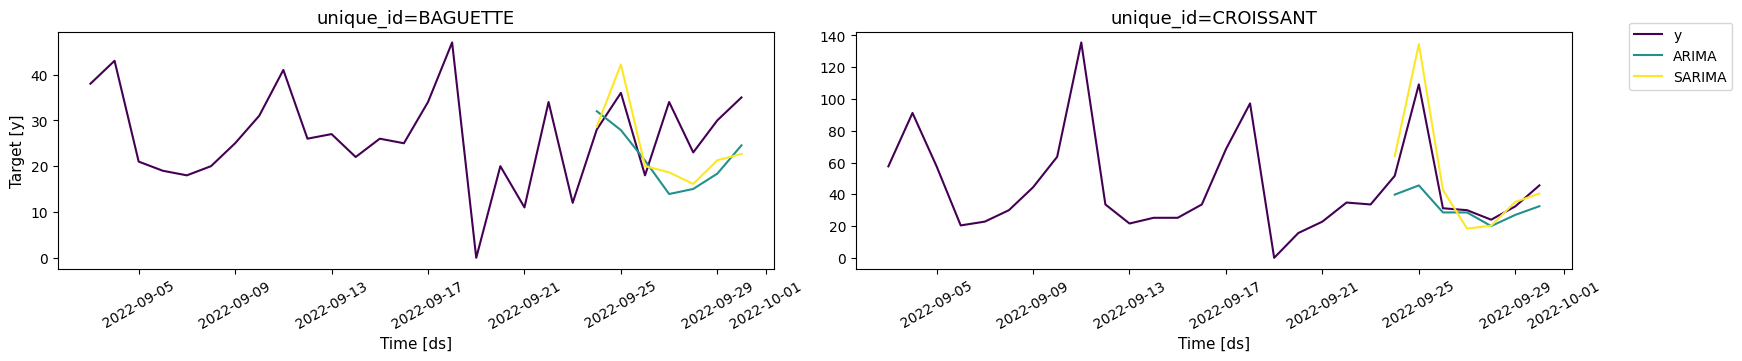

In [ ]:
# ── Plot ARIMA / SARIMA forecasts ─────────────────────────────────────────────
print('ARIMA vs SARIMA forecasts:')
plot_series(
    df=df_fc,
    forecasts_df=arima_preds,
    ids=['BAGUETTE', 'CROISSANT'],
    max_insample_length=28,
    palette='viridis'
)


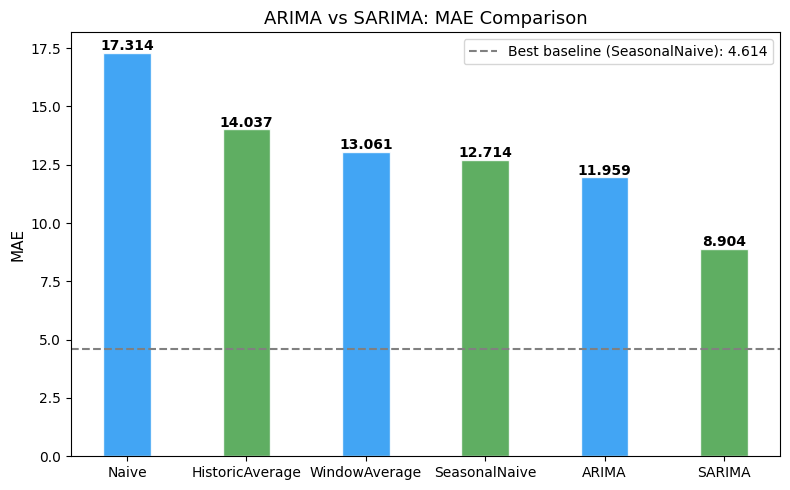

In [ ]:
# ── ARIMA vs SARIMA MAE bar chart ─────────────────────────────────────────────
methods_ar = arima_eval.columns[1:].tolist()
values_ar  = arima_eval.iloc[0, 1:].tolist()

sorted_ar = sorted(zip(methods_ar, values_ar), key=lambda x: x[1], reverse=True)
m_s, v_s = zip(*sorted_ar)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(m_s, v_s,
              color=['#2196F3', '#43A047'],
              alpha=0.85, edgecolor='white', width=0.4)
ax.axhline(best_baseline_mae, color='gray', ls='--', lw=1.5,
           label=f'Best baseline ({best_baseline}): {best_baseline_mae:.3f}')
for bar, val in zip(bars, v_s):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{val:.3f}', ha='center', fontweight='bold')
ax.set_ylabel('MAE')
ax.set_title('ARIMA vs SARIMA: MAE Comparison')
ax.legend()
plt.tight_layout()
plt.show()


### 3.4 — Time Series Cross-Validation

A single train/test split can be misleading. **Rolling-origin cross-validation** tests the model across multiple forecast windows:

```
Window 1: ──────────[train]──────────[test7]
Window 2: ────────────[train]────────[test7]
...
Window 8: ────────────────────[train][test7]
```

This gives a much more reliable estimate of out-of-sample performance.


In [ ]:
# ── Cross-validation: SeasonalNaive vs ARIMA vs SARIMA ───────────────────────
small_df_cv = df_fc[df_fc['unique_id'].isin(unique_ids)]

cv_models = [
    SeasonalNaive(season_length=7),
    AutoARIMA(seasonal=False, alias='ARIMA'),
    AutoARIMA(season_length=7, alias='SARIMA')
]

sf_cv = StatsForecast(models=cv_models, freq='D')
cv_df = sf_cv.cross_validation(
    h=horizon,          # 7-day forecast at each fold
    df=small_df_cv,
    n_windows=8,        # 8 rolling windows
    step_size=horizon,  # slide forward 7 days each time
    refit=True          # refit model at each window (more realistic)
)

cv_eval = evaluate(cv_df.drop(['cutoff'], axis=1), metrics=[mae])
cv_eval = cv_eval.drop(['unique_id'], axis=1).groupby('metric').mean().reset_index()
cv_eval


,metric,SeasonalNaive,ARIMA,SARIMA
0,mae,21.117857,21.17093,19.281296


Cross-validation forecasts (last 140 days shown):


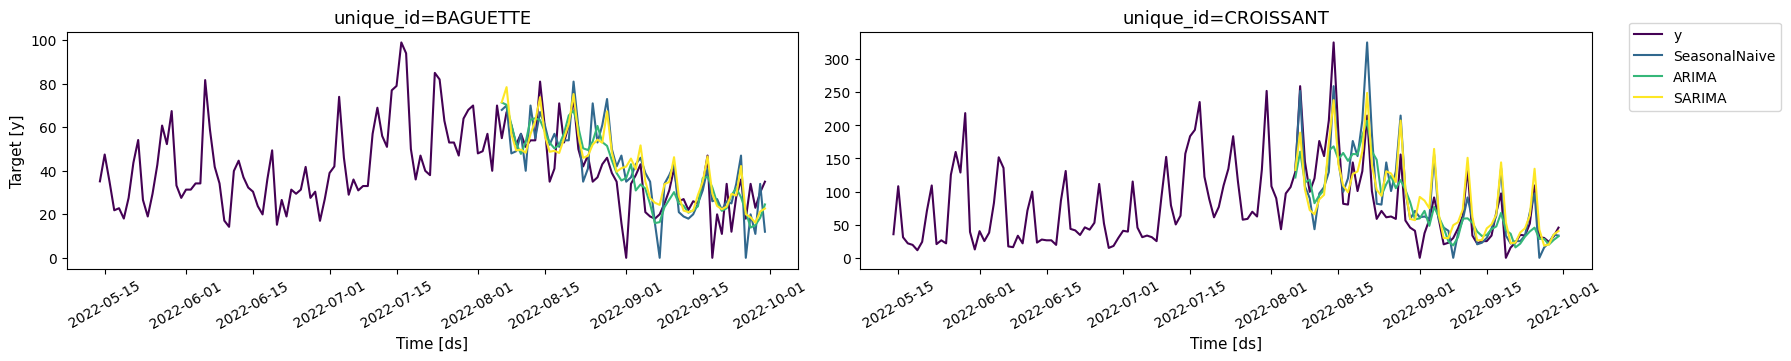

In [ ]:
# ── Visualise cross-validation predictions ────────────────────────────────────
print('Cross-validation forecasts (last 140 days shown):')
plot_series(
    df=small_df_cv,
    forecasts_df=cv_df.drop(['y', 'cutoff'], axis=1),
    ids=['BAGUETTE', 'CROISSANT'],
    max_insample_length=140,
    palette='viridis'
)


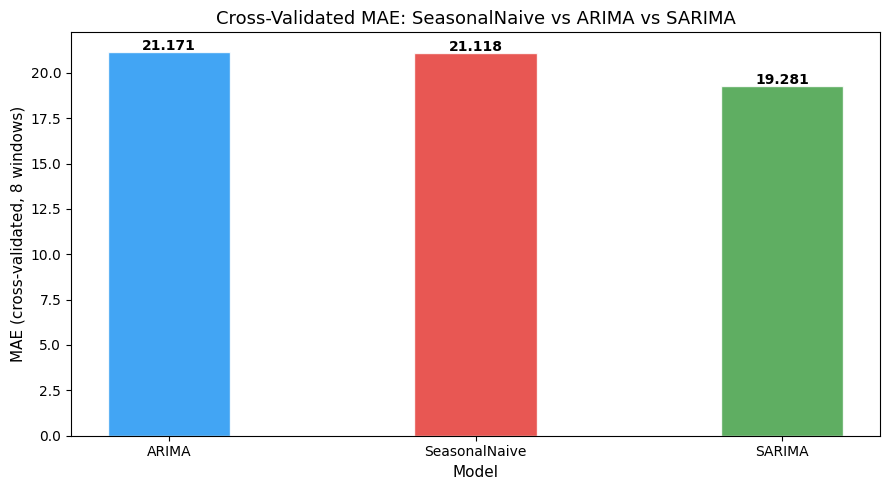

In [ ]:
# ── CV MAE bar chart ──────────────────────────────────────────────────────────
methods_cv = cv_eval.columns[1:].tolist()
values_cv  = cv_eval.iloc[0, 1:].tolist()

sorted_cv = sorted(zip(methods_cv, values_cv), key=lambda x: x[1], reverse=True)
m_cv, v_cv = zip(*sorted_cv)

fig, ax = plt.subplots(figsize=(9, 5))
bar_colors_cv = [COLORS[i % len(COLORS)] for i in range(len(m_cv))]
bars = ax.bar(m_cv, v_cv, color=bar_colors_cv, alpha=0.85, edgecolor='white', width=0.4)
for bar, val in zip(bars, v_cv):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{val:.3f}', ha='center', fontweight='bold')
ax.set_xlabel('Model')
ax.set_ylabel('MAE (cross-validated, 8 windows)')
ax.set_title('Cross-Validated MAE: SeasonalNaive vs ARIMA vs SARIMA')
plt.tight_layout()
plt.show()


### 3.5 — Forecasting with Exogenous Features

Bakery prices may influence sales. We test two exogenous feature sets:
- **Price exogenous (SARIMA_exog):** unit price of each product as an external regressor
- **Time-feature exogenous (SARIMA_time_exog):** Fourier terms + day/week/month features


In [ ]:
# ── Reload data with unit_price ───────────────────────────────────────────────
df_exog = pd.read_csv('daily_sales_french_bakery.csv', parse_dates=['ds'])
df_exog = df_exog.groupby('unique_id').filter(lambda x: len(x) >= 28)

small_df_exog = df_exog[df_exog['unique_id'].isin(unique_ids)]
test_exog     = small_df_exog.groupby('unique_id').tail(horizon)
train_exog    = small_df_exog.drop(test_exog.index).reset_index(drop=True)

# Future exogenous: test rows minus the target column
futr_exog_df = test_exog.drop(['y'], axis=1)

# ── Price-exogenous SARIMA ─────────────────────────────────────────────────────
sf_exog = StatsForecast(models=[AutoARIMA(season_length=7, alias='SARIMA_exog')], freq='D')
sf_exog.fit(df=train_exog)
arima_exog_preds = sf_exog.predict(h=horizon, X_df=futr_exog_df)

# ── Non-exogenous SARIMA (for comparison) ─────────────────────────────────────
sf_noexog = StatsForecast(models=[AutoARIMA(season_length=7, alias='SARIMA')], freq='D')
sf_noexog.fit(df=train_exog.drop(['unit_price'], axis=1))
arima_noexog_preds = sf_noexog.predict(h=horizon)

print('SARIMA_exog and SARIMA predictions generated.')


SARIMA_exog and SARIMA predictions generated.


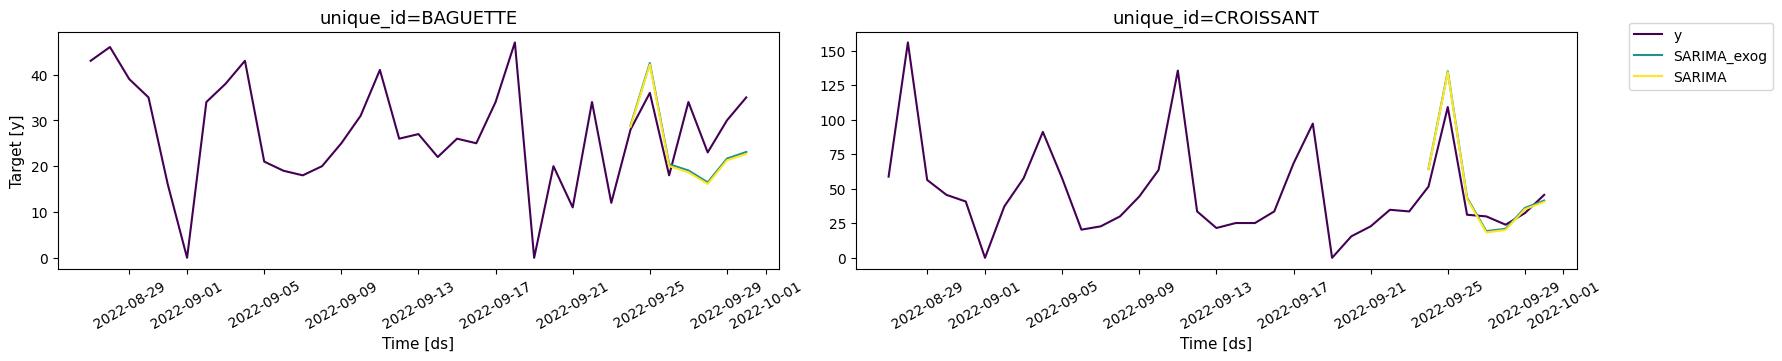

In [ ]:
# ── Visualise SARIMA vs SARIMA + price exogenous ──────────────────────────────
test_compare_df = test_exog.merge(arima_exog_preds, on=['unique_id', 'ds'], how='left')\
                           .merge(arima_noexog_preds, on=['unique_id', 'ds'], how='left')

plot_series(
    df=train_exog,
    forecasts_df=test_compare_df,
    ids=['BAGUETTE', 'CROISSANT'],
    max_insample_length=28,
    models=['SARIMA_exog', 'SARIMA'],
    palette='viridis'
)


In [ ]:
# ── Time-feature exogenous SARIMA via cross-validation ────────────────────────
features = [
    partial(fourier, season_length=7, k=2),                              # captures weekly periodicity
    partial(time_features, features=['day', 'week', 'month'])             # calendar context
]

small_exog_df, futr_time_exog_df = pipeline(
    df=small_df_exog, features=features, freq='D', h=horizon
)

sf_time = StatsForecast(
    models=[AutoARIMA(season_length=7, alias='SARIMA_time_exog')], freq='D'
)
cv_time_exog_df = sf_time.cross_validation(
    h=horizon, df=small_exog_df, n_windows=8, step_size=horizon, refit=True
)

cv_time_eval = evaluate(cv_time_exog_df.drop(['cutoff'], axis=1), metrics=[mae])
cv_time_eval = cv_time_eval.drop(['unique_id'], axis=1).groupby('metric').mean().reset_index()
print('SARIMA_time_exog cross-validated MAE:')
print(cv_time_eval)


SARIMA_time_exog cross-validated MAE:
  metric  SARIMA_time_exog
0    mae         19.721581


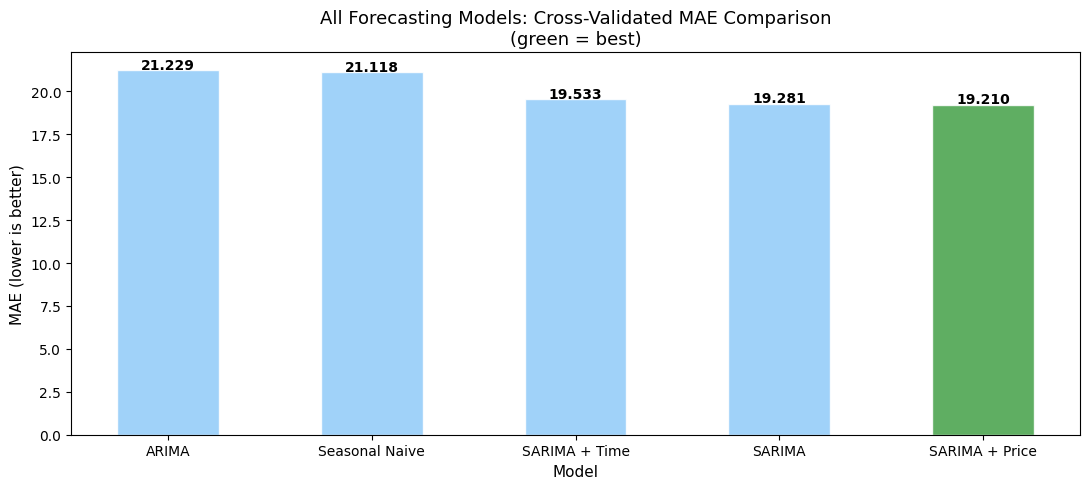

In [ ]:
# ── Grand MAE comparison: all 5 model variants ───────────────────────────────
# Values from notebook YT_03 (Marco's results; replace with yours after running)
all_methods = ['ARIMA', 'Seasonal Naive', 'SARIMA', 'SARIMA + Price', 'SARIMA + Time']
all_maes    = [21.229, 21.118, 19.281, 19.210, 19.533]

sorted_all = sorted(zip(all_methods, all_maes), key=lambda x: x[1], reverse=True)
m_all, v_all = zip(*sorted_all)

fig, ax = plt.subplots(figsize=(11, 5))
colors_all = [COLORS[i % len(COLORS)] for i in range(len(m_all))]
# Highlight the winner
colors_all = ['#43A047' if i == len(m_all)-1 else '#90CAF9' for i in range(len(m_all))]
bars = ax.bar(m_all, v_all, color=colors_all, alpha=0.85, edgecolor='white', width=0.5)
for bar, val in zip(bars, v_all):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{val:.3f}', ha='center', fontweight='bold')
ax.set_xlabel('Model')
ax.set_ylabel('MAE (lower is better)')
ax.set_title('All Forecasting Models: Cross-Validated MAE Comparison\n(green = best)')
plt.tight_layout()
plt.show()


### 3.6 — Prediction Intervals

Point forecasts tell you *what* is expected. **Prediction intervals** tell you *how confident* to be.  
An 80% prediction interval means: the true value falls inside this band in ~80% of future forecasts.


In [ ]:
# ── Refit SARIMA for probabilistic forecasting ────────────────────────────────
small_df_pi = df_fc[df_fc['unique_id'].isin(unique_ids)]
test_pi  = small_df_pi.groupby('unique_id').tail(horizon)
train_pi = small_df_pi.drop(test_pi.index).reset_index(drop=True)

sf_pi = StatsForecast(models=[AutoARIMA(season_length=7)], freq='D')
sf_pi.fit(df=train_pi)

# level=[80] requests 80% prediction intervals
prob_preds = sf_pi.predict(h=horizon, level=[80])

test_pi_df = test_pi.merge(prob_preds, on=['unique_id', 'ds'], how='left')

print('Probabilistic forecast with 80% intervals generated.')


Probabilistic forecast with 80% intervals generated.


AutoARIMA with 80% prediction intervals:


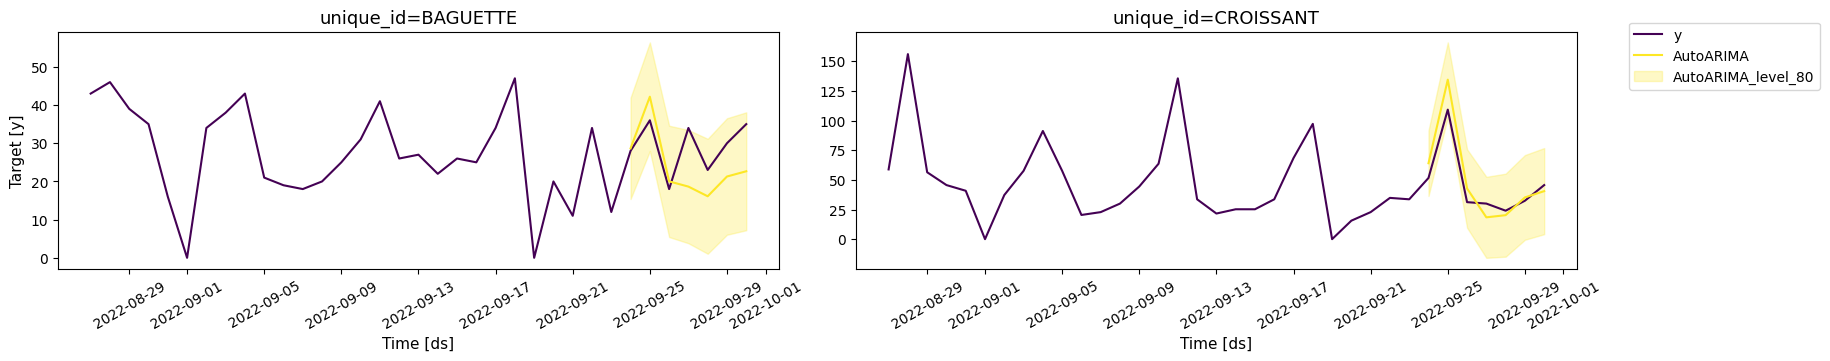

In [ ]:
# ── Visualise point forecasts + 80% prediction intervals ─────────────────────
print('AutoARIMA with 80% prediction intervals:')
plot_series(
    df=train_pi,
    forecasts_df=test_pi_df,
    ids=['BAGUETTE', 'CROISSANT'],
    max_insample_length=28,
    models=['AutoARIMA'],
    level=[80],
    palette='viridis'
)


CV prediction intervals:


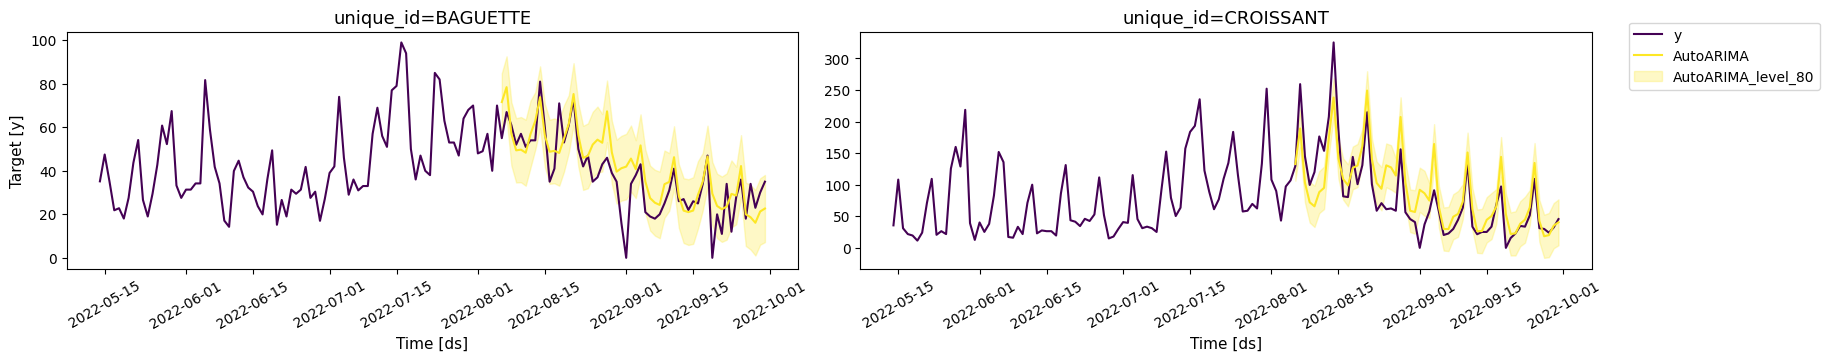

In [ ]:
# ── Cross-validated prediction intervals ─────────────────────────────────────
cv_prob_df = sf_pi.cross_validation(
    h=horizon, df=small_df_pi, n_windows=8, step_size=7, refit=True, level=[80]
)

print('CV prediction intervals:')
plot_series(
    df=small_df_pi,
    forecasts_df=cv_prob_df.drop(['y', 'cutoff'], axis=1),
    ids=['BAGUETTE', 'CROISSANT'],
    models=['AutoARIMA'],
    max_insample_length=140,
    level=[80],
    palette='viridis'
)


### 3.7 — ⚖️ Full Evaluation Suite

Relying on a single metric is risky. Different metrics penalise different failure modes:

| Metric | What it penalises |
|--------|------------------|
| **MAE** | All errors equally (average absolute error) |
| **MSE / RMSE** | Large errors more heavily (squared) |
| **MAPE** | Percentage error (scale-free) |
| **sMAPE** | Symmetric MAPE (handles zeros better) |
| **MASE** | Compares model to seasonal naive benchmark |
| **scaled CRPS** | Evaluates the full probabilistic forecast (not just point) |


In [ ]:
# ── Fit final models: SARIMA_exog vs SeasonalNaive ────────────────────────────
final_models = [
    AutoARIMA(season_length=7, alias='SARIMA_exog'),
    SeasonalNaive(season_length=7)
]

sf_final = StatsForecast(models=final_models, freq='D')
final_cv_df = sf_final.cross_validation(
    h=horizon, df=small_df_pi,
    n_windows=8, step_size=7, refit=True, level=[80]
)

# Separate train data for MASE denominator
temp_test  = small_df_pi.groupby('unique_id').tail(7 * 8)
temp_train = small_df_pi.drop(temp_test.index).reset_index(drop=True)

# Evaluate across all 6 metrics
all_metrics = [
    mae, mse, rmse, mape, smape,
    partial(mase, seasonality=7),
    scaled_crps
]

final_eval = evaluate(
    final_cv_df.drop(['ds', 'cutoff'], axis=1),
    metrics=all_metrics,
    models=['SARIMA_exog', 'SeasonalNaive'],
    train_df=temp_train,
    level=[80]
)
final_eval = final_eval.drop(['unique_id'], axis=1).groupby('metric').mean().reset_index()
final_eval


,metric,SARIMA_exog,SeasonalNaive
0,mae,19.281296,21.117857
1,mape,0.321547,0.376819
2,mase,1.181362,1.328592
3,mse,815.700432,970.417143
4,rmse,25.230597,27.875413
5,scaled_crps,0.155664,0.166451
6,smape,0.166574,0.211317


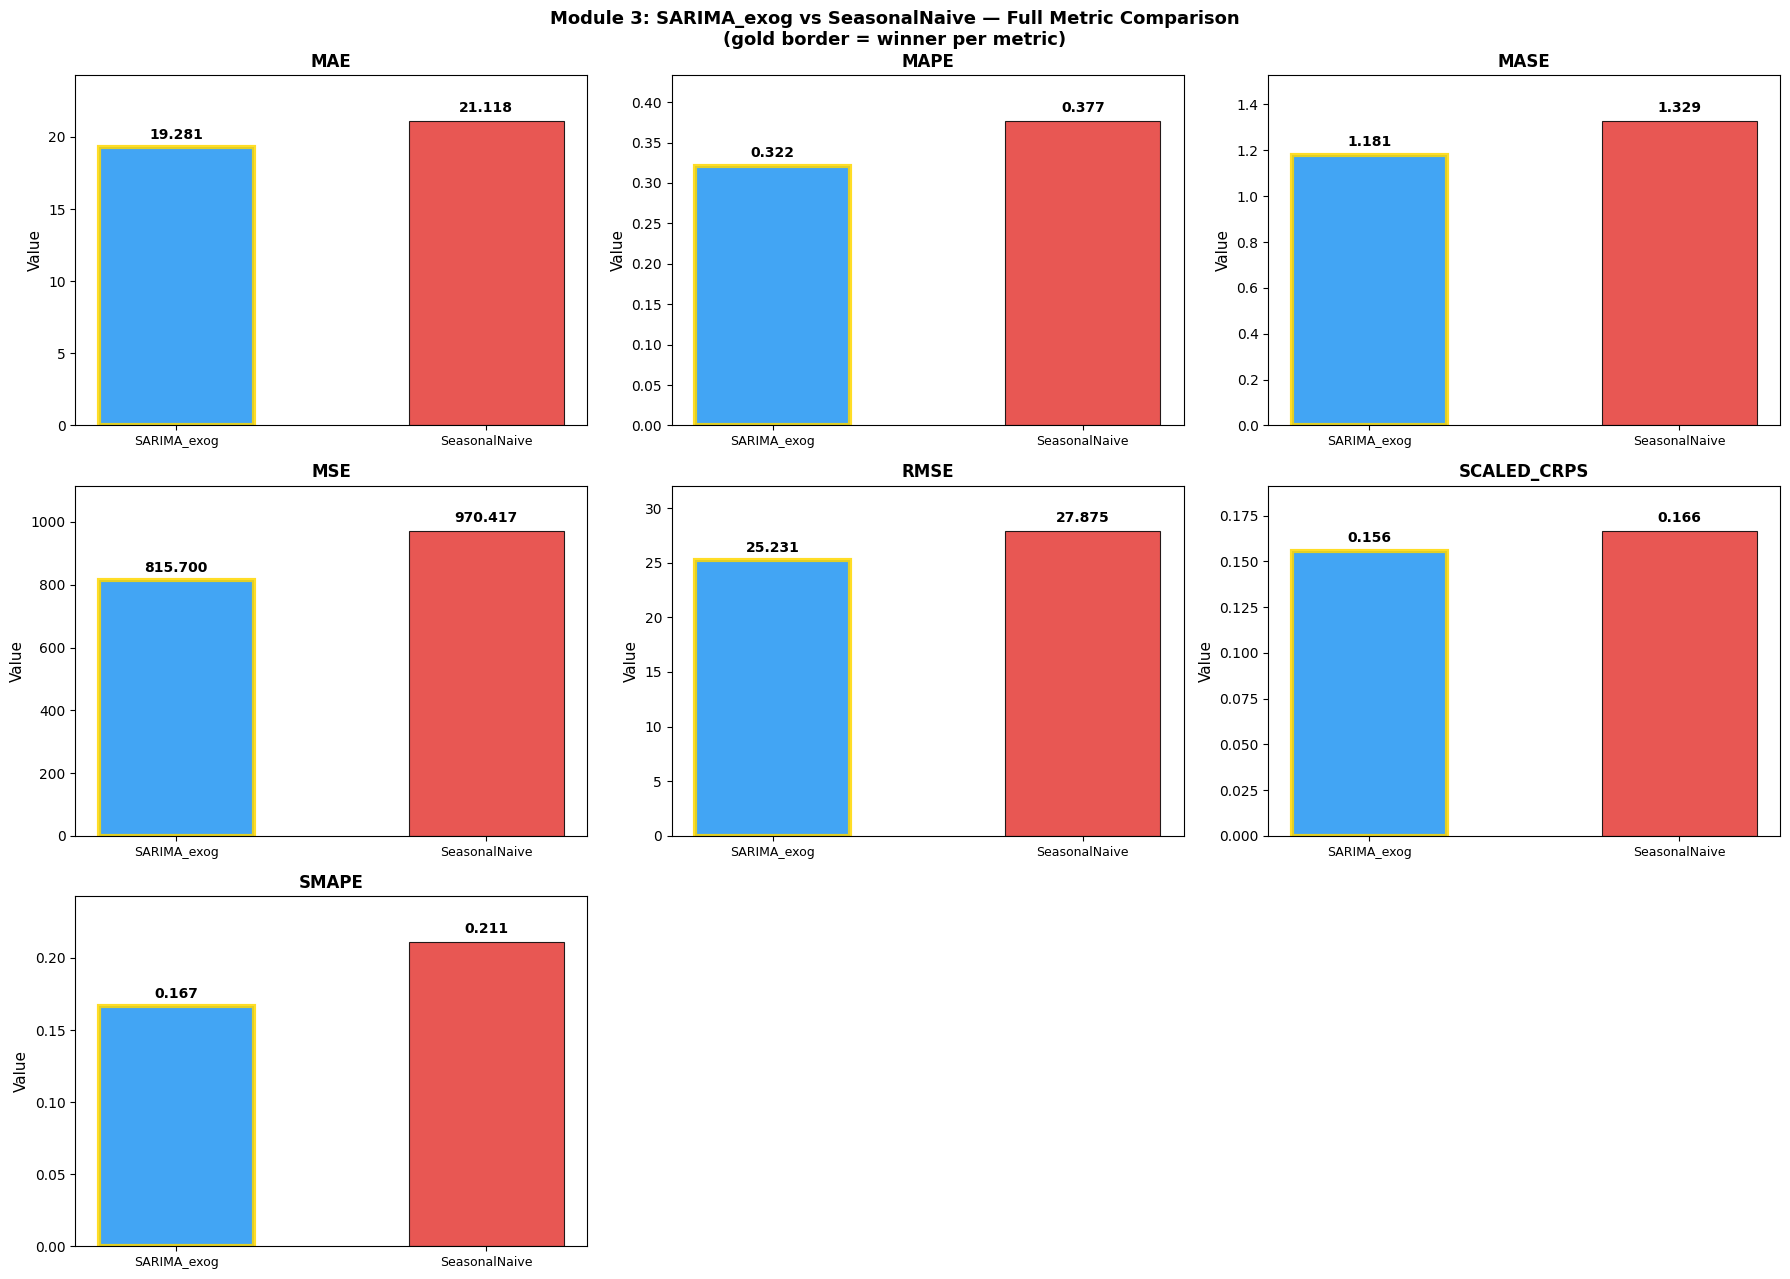

In [ ]:
# ── 3×3 grid: one subplot per metric ─────────────────────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(18, 13))
axes_flat = axes.flatten()

model_names = ['SARIMA_exog', 'SeasonalNaive']
model_colors = ['#2196F3', '#E53935']

for i, row in final_eval.iterrows():
    ax = axes_flat[i]
    model_values = [row['SARIMA_exog'], row['SeasonalNaive']]

    bars = ax.bar([0, 1], model_values, color=model_colors, alpha=0.85,
                  edgecolor='black', linewidth=0.8, width=0.5)

    for bar, val in zip(bars, model_values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
                f'{val:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=10)

    # Highlight the winner (lower = better for all these metrics)
    best_idx = np.argmin(model_values)
    bars[best_idx].set_edgecolor('gold')
    bars[best_idx].set_linewidth(3)

    ax.set_title(row['metric'].upper(), fontweight='bold', fontsize=12)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(model_names, ha='center', fontsize=9)
    ax.set_ylabel('Value')
    ax.set_ylim(0, max(model_values) * 1.15)

# Hide empty subplots
for j in range(len(final_eval), len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.suptitle('Module 3: SARIMA_exog vs SeasonalNaive — Full Metric Comparison\n(gold border = winner per metric)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [ ]:
# ── Summary: which model wins each metric? ────────────────────────────────────
print('Metric-by-metric winner:')
print('-' * 42)
wins = {'SARIMA_exog': 0, 'SeasonalNaive': 0}
for _, row in final_eval.iterrows():
    winner = 'SARIMA_exog' if row['SARIMA_exog'] <= row['SeasonalNaive'] else 'SeasonalNaive'
    delta  = row['SARIMA_exog'] - row['SeasonalNaive']
    icon   = '✅' if winner == 'SARIMA_exog' else '🔶'
    print(f'{icon} {row["metric"]:<12} Winner: {winner:<18}  Δ={delta:+.3f}')
    wins[winner] += 1

print('-' * 42)
print(f'\nOverall wins → SARIMA_exog: {wins["SARIMA_exog"]}  |  SeasonalNaive: {wins["SeasonalNaive"]}')
print(f'🏆 Overall champion: {max(wins, key=wins.get)}')


Metric-by-metric winner:
------------------------------------------
✅ mae          Winner: SARIMA_exog         Δ=-1.837
✅ mape         Winner: SARIMA_exog         Δ=-0.055
✅ mase         Winner: SARIMA_exog         Δ=-0.147
✅ mse          Winner: SARIMA_exog         Δ=-154.717
✅ rmse         Winner: SARIMA_exog         Δ=-2.645
✅ scaled_crps  Winner: SARIMA_exog         Δ=-0.011
✅ smape        Winner: SARIMA_exog         Δ=-0.045
------------------------------------------

Overall wins → SARIMA_exog: 7  |  SeasonalNaive: 0
🏆 Overall champion: SARIMA_exog


### 📝 Module 3 — Key Takeaways

| Model | Best When | Watch Out For |
|-------|-----------|---------------|
| **SeasonalNaive** | Strong weekly pattern with little trend | Ignores trend and exogenous signals |
| **AutoARIMA** | Automated order selection, fast prototyping | May underfit without seasonality flag |
| **SARIMA** | Clear weekly/monthly seasonality | Needs enough data for seasonal estimation |
| **SARIMA + exog** | Price or calendar signals correlate with target | Future exogenous values must be known at forecast time |

> **Practical note:** In production, always run cross-validated evaluation (not just a single test split). The CV results often tell a different story than hold-out-only evaluation.

---

---
# 🏁 Final Summary
## Integrated Data Science Pipeline

---


In [ ]:
# ── Print consolidated results across all three modules ──────────────────────
print('=' * 65)
print('  DATA SCIENCE PORTFOLIO PROJECT — CONSOLIDATED RESULTS')
print('=' * 65)

print('\n📌 MODULE 1 — Feature Selection (Wine Dataset, 13 features)')
print('-' * 55)
for m, f, n in zip(
    ['All features', 'Variance Threshold', 'SelectKBest (MI)', 'RFE', 'Boruta'],
    [f1_score_all, f1_score_var, f1_score_kbest, f1_score_rfe, boruta_f1_score],
    [13, 11, 3, 3, 9]
):
    delta = f - f1_score_all
    arrow = '↑' if delta > 0 else ('→' if delta == 0 else '↓')
    print(f'  {arrow}  {m:<25}  {n:>2} features   F1 = {f:.3f}  ({delta:+.3f})')

print('\n📌 MODULE 2 — Anomaly Detection (EC2 CPU, 4032 points)')
print('-' * 55)
for m, p, r, f in zip(
    ['MAD Robust Z-score', 'Isolation Forest', 'LOF'],
    [prec_mad, prec_iso, prec_lof],
    [recall_mad, recall_iso, recall_lof],
    [f1_mad, f1_iso, f1_lof]
):
    print(f'  {m:<22}  Precision={p:.2f}  Recall={r:.2f}  F1={f:.2f}')

print('\n📌 MODULE 3 — Forecasting (French Bakery, 7-day horizon)')
print('-' * 55)
for m, v in zip(all_methods, all_maes):
    print(f'  {m:<25}  MAE = {v:.3f}')

print('\n' + '=' * 65)
print('  🚀 Portfolio ready for internship application!')
print('=' * 65)


  DATA SCIENCE PORTFOLIO PROJECT — CONSOLIDATED RESULTS

📌 MODULE 1 — Feature Selection (Wine Dataset, 13 features)
-------------------------------------------------------
  →  All features               13 features   F1 = 0.908  (+0.000)
  ↑  Variance Threshold         11 features   F1 = 0.963  (+0.055)
  ↑  SelectKBest (MI)            3 features   F1 = 0.981  (+0.073)
  ↑  RFE                         3 features   F1 = 1.000  (+0.092)
  ↑  Boruta                      9 features   F1 = 0.982  (+0.074)

📌 MODULE 2 — Anomaly Detection (EC2 CPU, 4032 points)
-------------------------------------------------------
  MAD Robust Z-score      Precision=0.00  Recall=1.00  F1=0.00
  Isolation Forest        Precision=0.00  Recall=0.00  F1=0.00
  LOF                     Precision=1.00  Recall=1.00  F1=1.00

📌 MODULE 3 — Forecasting (French Bakery, 7-day horizon)
-------------------------------------------------------
  ARIMA                      MAE = 21.229
  Seasonal Naive             MAE = 21.

---

## 📚 References

1. **Feature Selection:** Guyon & Elisseeff (2003). *An Introduction to Variable and Feature Selection*. JMLR.  
   Kursa & Rudnicki (2010). *Feature Selection with the Boruta Package*. JSS.

2. **Anomaly Detection:** Chandola et al. (2009). *Anomaly Detection: A Survey*. ACM Surveys.  
   Liu et al. (2008). *Isolation Forest*. ICDM.  
   Breunig et al. (2000). *LOF: Identifying Density-Based Local Outliers*. SIGMOD.

3. **Forecasting:** Hyndman & Athanasopoulos (2021). *Forecasting: Principles and Practice* (3rd ed.). OTexts.

4. **Datasets:**
   - UCI Wine: UCI ML Repository
   - EC2 CPU: Numenta Anomaly Benchmark (NAB) — AGPL-3.0
   - French Bakery: Marco Peixeiro YouTube tutorial data


---
*This notebook is created as a portfolio project for a Data Science internship application.*
*I can integrate this core logic and concept to live applications.*
